In [1]:
# import pandas as pd

# df1 = pd.read_csv("results/Thesis_Phase_v3_grade_run_scores.csv")
# df2 = pd.read_csv("results/Thesis_Phase_v3.2_grade_run_scores.csv")
# combined_df = pd.concat([df1, df2], ignore_index=True)
# combined_df.to_csv("H:/My Drive/UdS/Thesis/LLaMA-Factory/experiments/scripts/results/combined_grade_run_scores.csv", index=False)
# results = pd.read_csv("H:/My Drive/UdS/Thesis/LLaMA-Factory/experiments/scripts/results/combined_grade_run_scores.csv")
# print(results.head())
# print(len(results))
# print(len(results['run_name'].value_counts()))

In [2]:
# import wandb
# import pandas as pd
# import re
# from collections import Counter
# from tqdm import tqdm
# api = wandb.Api()
# grade_re = re.compile(r"eval/cleaned_grade(\d+)_validation_(.+)$")

# PROJECT = "Thesis_Phase_v3.1"
# DFKGL_VARIANT = "pred-tgt-dFKGL"   # <- change to "label-tgt-dFKGL" or "pred-tgt-dFKGL" if needed


In [3]:


# def extract_per_grade(summary_items):
#     """
#     Returns:
#       sari_by_grade: dict[int] -> float
#       dfkgl_by_grade: dict[int] -> float
#       bert_score_by_grade: dict[int] -> float
#     """
#     sari_by_grade = {}
#     dfkgl_by_grade = {}
#     bert_score_by_grade = {}

#     for k, v in summary_items:
#         if v is None:
#             continue

#         m = grade_re.match(k)
#         if not m:
#             continue

#         grade = int(m.group(1))
#         metric_tail = m.group(2)

#         # SARI can appear as ..._sari or ..._SARI
#         if metric_tail in ("sari", "SARI"):
#             sari_by_grade[grade] = float(v)

#         # dFKGL variant (e.g. pred-label-dFKGL)
#         if metric_tail == DFKGL_VARIANT:
#             dfkgl_by_grade[grade] = float(v)

#         if metric_tail == "BERTScore_F1":
#             bert_score_by_grade[grade] = float(v)

#     return sari_by_grade, dfkgl_by_grade, bert_score_by_grade

# def avg(vals):
#     vals = list(vals)
#     return sum(vals) / len(vals) if vals else None


# def download_runs(project_name):
#     runs = api.runs(f"uds/{project_name}")
#     #print(f"Found {len(runs)} runs in {ENTITY}/{SRC_PROJECT}")
#     score_dataframes = []

#     for src_run in tqdm(runs):
#         # look for runs with missing grades, should have 39 keys in summary metrics
#         items = {k: v for k, v in src_run.summary.items() if v is not None}
#         if len(items) < 39 and len(items) != 11:
#             print(src_run.name)

# download_runs("Thesis_Phase_v3.1")

In [4]:
import pandas as pd
import regex as re
raw_results = pd.read_csv("H:/My Drive/UdS/Thesis/LLaMA-Factory/experiments/scripts/results/combined_grade_run_scores_cleaned.csv")
#print(results['run_name'].value_counts())
for name, group in raw_results.groupby('run_name'):
    print(name)

for counts in raw_results['run_name'].value_counts().items():
    if counts[1] !=11:
        print(counts)

dare_ties_g@all_ws@all_w@uniform-average
dare_ties_ws@1-copies_w@uniform-average
dare_ties_ws@10-copies_w@uniform-average
dare_ties_ws@10_w@random-1-average
dare_ties_ws@10_w@random-2-average
dare_ties_ws@10_w@random-3-average
dare_ties_ws@11-copies_w@uniform-average
dare_ties_ws@11_w@random-1-average
dare_ties_ws@11_w@random-2-average
dare_ties_ws@11_w@random-3-average
dare_ties_ws@12_w@random-1-average
dare_ties_ws@12_w@random-2-average
dare_ties_ws@12_w@random-3-average
dare_ties_ws@1_w@doubled-average
dare_ties_ws@1_w@halved-average
dare_ties_ws@1_w@proximity-average
dare_ties_ws@1_w@proximity-cubed-average
dare_ties_ws@1_w@proximity-flatter-average
dare_ties_ws@1_w@proximity-squared-average
dare_ties_ws@1_w@proximity-sum
dare_ties_ws@1_w@tripled-average
dare_ties_ws@1_w@uniform-average
dare_ties_ws@1_w@uniform-downshifted-1
dare_ties_ws@1_w@uniform-downshifted-2
dare_ties_ws@1_w@uniform-no_tgt_grade
dare_ties_ws@1_w@uniform-sum
dare_ties_ws@1_w@uniform-upshifted-1
dare_ties_ws@1_w

In [5]:
results = raw_results.copy()
print(results.head())

                 run_name  grade       sari     dfkgl  bertF1
0  off-the-shelf-baseline      2  35.389355  4.505078   86.10
1  off-the-shelf-baseline      3  34.624633  4.262695   86.88
2  off-the-shelf-baseline      4  35.404793  3.900586   86.94
3  off-the-shelf-baseline      5  35.847947  3.589062   87.18
4  off-the-shelf-baseline      6  34.126446  3.497461   87.21


In [6]:
# rename 'run_name' containing dare_ties to dareties
results = raw_results.copy()
results['run_name'] = results['run_name'].str.replace('dare_ties', 'dareties')
results['window_size'] = results['run_name'].str.extract(r'ws@(\d+|all)_')[0]
results['window_size'] = results['window_size'].replace('10', 'all')
results['window_size'] = results['window_size'].replace('11', 'all')
results['window_size'] = results['window_size'].replace('12', 'all')
results['window_size'] = results['window_size'].fillna('0')
results['window_size'] = results['window_size'].replace('all', '12')
results['window_size'] = results['window_size'].astype(int)
low = (results["grade"] - results["window_size"]).clip(lower=2)
high = (results["grade"] + results["window_size"]).clip(upper=12)
results["n_adapters"] = high - low + 1
# adapters from run_name 'no-tgt-grade' need to minus 1 from n_adapters
results.loc[results['run_name'].str.contains('no-tgt-grade'), 'n_adapters'] -= 1
results['run_name'] = results['run_name'].str.replace('-average', '_average')
results['run_name'] = results['run_name'].str.replace('-sum', '_sum')
results['run_name'] = results['run_name'].str.replace('uniform-', 'uniform_')
results['run_name'] = results['run_name'].str.replace('no_tgt_grade', 'no-tgt-grade')
results['run_name'] = results['run_name'].str.replace('Shared Baseline', 'shared-baseline')
results['merge_method'] = results['run_name'].str.extract(r'(linear|dareties)')[0]
results['weight_method'] = results['run_name'].str.extract(r'(uniform|proximity|random|halved|doubled|tripled|copies)')[0]
results['weight_method'] = results['weight_method'].str.replace('halved', 'uniform')
results['weight_method'] = results['weight_method'].str.replace('doubled', 'uniform')
results['weight_method'] = results['weight_method'].str.replace('tripled', 'uniform')
results['weight_method'] = results['weight_method'].str.replace('copies', 'uniform')
weight_avg_map = {
    'sum': round(1/11, 2),
    'halved': 0.5,
    'double': 2.0,
    'triple': 3.0,
    'graded': 0,
    'baseline': 0,
    'downshifted': 1.0,
    'upshifted': 1.0,
    'random': 1.0,
    'uniform_average': 1.0,
    'proximity_average': 1.0,
    'no-tgt-grade': 1.0,
    'flatter': 1.0,
    }
# results['weight_average'] = results['run_name'].str.extract( {term from weight_avg_map} )
results['weight_average'] = results['run_name'].apply(
    lambda x: next((v for k, v in weight_avg_map.items() if k in x), None)
)
# results weight_scheme should copy run_name with ws@n removed
results['weight_scheme'] = results['run_name'].str.replace(r'_ws@\d+', '', regex=True)
results['weight_scheme'] = results['weight_scheme'].str.replace(r'_ws@all', '', regex=True)
results['n_adapters'] = results.apply(
    lambda row: int(re.search(r'dareties_ws@(\d+)-copies_w@uniform_average', row['run_name']).group(1))
    if row['weight_scheme'] == 'dareties-copies_w@uniform_average' and re.search(r'dareties_ws@(\d+)-copies_w@uniform_average', row['run_name'])
    else row['n_adapters'],
    axis=1
)
results['window_size'] = results.apply(
    lambda row: (row['n_adapters'] - 1) / 2
    if row['weight_scheme'] == 'dareties-copies_w@uniform_average'
    else row['window_size'],
    axis=1
)
print(results['weight_scheme'].unique())

# for run_name in results['run_name'].unique():
#    print(run_name)

['off-the-shelf-baseline' 'shared-warmup' 'graded-from-shared-warmup'
 'dareties_g@all_w@uniform_average' 'dareties_w@uniform_average'
 'dareties_w@proximity_average' 'graded-from-off-the-shelf'
 'dareties_w@proximity_sum' 'dareties_w@uniform_sum'
 'ots_dareties_w@proximity_average' 'ots_dareties_w@uniform_average'
 'dareties_w@uniform_no-tgt-grade' 'dareties_w@uniform_downshifted-2'
 'dareties_w@uniform_downshifted-1' 'dareties_w@proximity-cubed_average'
 'dareties_w@proximity-flatter_average'
 'dareties_w@proximity-squared_average' 'dareties_w@uniform_upshifted-1'
 'dareties_w@uniform_upshifted-2' 'dareties_w@halved_average'
 'dareties_w@doubled_average' 'dareties_w@tripled_average'
 'dareties_w@random-1_average' 'dareties_w@random-3_average'
 'dareties_w@random-2_average' 'linear_w@uniform_average'
 'dareties-copies_w@uniform_average' 'linear_w@uniform_sum'
 'linear_w@proximity_sum' 'linear_w@proximity_average']


In [7]:
results['window_size'].value_counts()

window_size
2.0     242
4.0     242
1.0     242
3.0     242
5.0     242
12.0    110
0.0      55
0.5      11
1.5      11
2.5      11
3.5      11
4.5      11
Name: count, dtype: int64

In [8]:
column = 'window_size'
print(results[column].unique())
print(results[column].value_counts())
size_comparisons = []
for size in sorted(results['window_size'].unique()):
    if size == 'all' or size == '0':
        continue
    subset = results[results['window_size'] == size]
    run_names = sorted(subset['run_name'].unique().tolist())
    print(size, len(run_names))
    while len(run_names) < 21:
        run_names.append(None)
    size_comparisons.append(run_names)

# zip and compare
for runs in zip(*size_comparisons):
    print(runs)


[ 0.  12.   4.   2.   3.   1.   5.   0.5  1.5  2.5  3.5  4.5]
window_size
2.0     242
4.0     242
1.0     242
3.0     242
5.0     242
12.0    110
0.0      55
0.5      11
1.5      11
2.5      11
3.5      11
4.5      11
Name: count, dtype: int64
0.0 5
0.5 1
1.0 22
1.5 1
2.0 22
2.5 1
3.0 22
3.5 1
4.0 22
4.5 1
5.0 22
12.0 10
('dareties_ws@1-copies_w@uniform_average', 'dareties_ws@2-copies_w@uniform_average', 'dareties_ws@1_w@doubled_average', 'dareties_ws@4-copies_w@uniform_average', 'dareties_ws@2_w@doubled_average', 'dareties_ws@6-copies_w@uniform_average', 'dareties_ws@3_w@doubled_average', 'dareties_ws@8-copies_w@uniform_average', 'dareties_ws@4_w@doubled_average', 'dareties_ws@10-copies_w@uniform_average', 'dareties_ws@11-copies_w@uniform_average', 'dareties_g@all_ws@all_w@uniform_average')
('graded-from-off-the-shelf', None, 'dareties_ws@1_w@halved_average', None, 'dareties_ws@2_w@halved_average', None, 'dareties_ws@3_w@halved_average', None, 'dareties_ws@4_w@halved_average', None, '

In [9]:
print(len(results))

1430


In [10]:
df = results.copy()

block_means = (
    df.groupby(["merge_method", "window_size", "grade", "weight_method"], as_index=False)
      .agg(mean_err=("dfkgl", "mean"))
)

summary = (
    block_means.groupby("weight_method", as_index=False)
               .agg(overall_mean_err=("mean_err", "mean"),
                    overall_std_err=("mean_err", "std"),
                    n_blocks=("mean_err", "size"))
               .sort_values("overall_mean_err")
)

summary


,weight_method,overall_mean_err,overall_std_err,n_blocks
1,random,9.122727,1.953481,11
2,uniform,17.894079,31.012687,187
0,proximity,29.931220,38.489093,110


In [11]:
wins = (
    block_means.loc[
        block_means.groupby(["merge_method", "window_size", "grade"])["mean_err"].idxmin()
    ]
)

win_rate = (
    wins["weight_method"].value_counts(normalize=True)
        .rename("win_rate")
        .reset_index()
        .rename(columns={"index": "weight_method"})
)

win_rate

,weight_method,win_rate
0,uniform,0.540107
1,proximity,0.459893


In [12]:
grade_summary = (
    block_means.groupby(["grade", "weight_method"], as_index=False)
              .agg(mean_err=("mean_err", "mean"))
              .sort_values(["grade", "mean_err"])
)

best_per_grade = (
    grade_summary.loc[grade_summary.groupby("grade")["mean_err"].idxmin()]
)

best_per_grade

,grade,weight_method,mean_err
1,2,random,6.537609
4,3,random,7.175499
7,4,random,6.670378
10,5,random,7.978125
13,6,random,8.081532
16,7,random,9.860091
19,8,random,10.287500
22,9,random,9.676541
25,10,random,10.237826
28,11,random,12.196940


In [13]:
blocks_per_method = (
    df.groupby(["merge_method", "window_size", "grade", "weight_method"])
      .size()
      .reset_index(name="n_models_in_block")
)

blocks_per_method["weight_method"].value_counts()

weight_method
uniform      187
proximity    110
random        11
Name: count, dtype: int64

In [14]:
row_weighted = (
    df.groupby("weight_method", as_index=False)
      .agg(mean_err=("dfkgl", "mean"),
           median_err=("dfkgl", "median"),
           std_err=("dfkgl", "std"),
           n=("dfkgl", "size"))
      .sort_values("mean_err")
)

row_weighted


,weight_method,mean_err,median_err,std_err,n
1,random,9.122727,3.708789,8.861620,99
2,uniform,10.827142,1.227539,29.183199,847
0,proximity,15.742773,1.338379,40.087202,440


In [15]:
block_means = (
    df.groupby(["merge_method", "window_size", "grade", "weight_method"], as_index=False)
      .agg(mean_err=("dfkgl", "mean"))
)

# keep only blocks where all 3 methods exist
complete_blocks = (
    block_means.groupby(["merge_method", "window_size", "grade"])["weight_method"]
              .nunique()
              .reset_index(name="n_methods")
)

block_means_complete = block_means.merge(
    complete_blocks.query("n_methods == 3")[["merge_method", "window_size", "grade"]],
    on=["merge_method", "window_size", "grade"],
    how="inner"
)

summary_complete = (
    block_means_complete.groupby("weight_method", as_index=False)
                       .agg(overall_mean_err=("mean_err", "mean"),
                            overall_median_err=("mean_err", "median"),
                            n_blocks=("mean_err", "size"))
                       .sort_values("overall_mean_err")
)

summary_complete


,weight_method,overall_mean_err,overall_median_err,n_blocks


In [16]:
wins_complete = block_means_complete.loc[
    block_means_complete.groupby(["merge_method", "window_size", "grade"])["mean_err"].idxmin()
]

win_rate_complete = (
    wins_complete["weight_method"].value_counts(normalize=True)
        .rename("win_rate")
        .reset_index()
        .rename(columns={"index": "weight_method"})
)

win_rate_complete


,weight_method,win_rate


In [17]:
primary_comparison = (
    df.groupby("weight_method", as_index=False)
      .agg(
          mean_dfkgl=("dfkgl", "mean"),
          median_dfkgl=("dfkgl", "median"),
          std_dfkgl=("dfkgl", "std"),
          n=("dfkgl", "size")
      )
      .sort_values("mean_dfkgl")
)

primary_comparison


,weight_method,mean_dfkgl,median_dfkgl,std_dfkgl,n
1,random,9.122727,3.708789,8.861620,99
2,uniform,10.827142,1.227539,29.183199,847
0,proximity,15.742773,1.338379,40.087202,440


In [18]:
df.groupby("weight_method")["dfkgl"].describe()

,count,mean,std,min,25%,50%,75%,max
weight_method,,,,,,,,
proximity,440.0,15.742773,40.087202,0.891797,1.085107,1.338379,4.380176,341.087500
random,99.0,9.122727,8.861620,0.941016,1.283496,3.708789,17.994629,27.077539
uniform,847.0,10.827142,29.183199,0.840039,1.039160,1.227539,3.930371,340.377930


In [19]:
primary_comparison = (
    df.groupby("weight_method", as_index=False)
      .agg(
          median_dfkgl=("dfkgl", "median"),
          mean_dfkgl=("dfkgl", "mean"),
          n=("dfkgl", "size")
      )
      .sort_values("median_dfkgl")
)

primary_comparison

,weight_method,median_dfkgl,mean_dfkgl,n
2,uniform,1.227539,10.827142,847
0,proximity,1.338379,15.742773,440
1,random,3.708789,9.122727,99


In [20]:
from scipy.stats import trim_mean

trimmed = (
    df.groupby("weight_method")
      .apply(lambda x: trim_mean(x["dfkgl"], 0.05))
      .reset_index(name="trimmed_mean_dfkgl")
      .sort_values("trimmed_mean_dfkgl")
)

trimmed

C:\Users\William\AppData\Local\Temp\ipykernel_35872\1893547813.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: trim_mean(x["dfkgl"], 0.05))


,weight_method,trimmed_mean_dfkgl
2,uniform,5.610852
0,proximity,8.515443
1,random,8.740071


In [21]:
within_1 = (
    df.assign(within_1 = df["dfkgl"] <= 1)
      .groupby("weight_method")["within_1"]
      .mean()
      .reset_index(name="pct_within_1_grade")
)

within_1

,weight_method,pct_within_1_grade
0,proximity,0.102273
1,random,0.030303
2,uniform,0.160567


In [22]:
import numpy as np

def trimmed_median(x, trim=0.05):
    x = np.sort(x)
    n = len(x)
    k = int(np.floor(trim * n))
    if n - 2*k <= 0:
        return np.nan
    return np.median(x[k : n - k])


In [23]:
trimmed_median_summary = (
    df.groupby("weight_method")
      .apply(lambda g: trimmed_median(g["dfkgl"], trim=0.05))
      .reset_index(name="trimmed_median_dfkgl")
      .sort_values("trimmed_median_dfkgl")
)

trimmed_median_summary


C:\Users\William\AppData\Local\Temp\ipykernel_35872\3994154976.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: trimmed_median(g["dfkgl"], trim=0.05))


,weight_method,trimmed_median_dfkgl
2,uniform,1.227539
0,proximity,1.338379
1,random,3.708789


In [24]:
for t in [0.0, 0.10, 0.25, 0.4]:
    print(f"\nTrim = {t}")
    print(
        df.groupby("weight_method")
          .apply(lambda g: trimmed_median(g["dfkgl"], trim=t))
          .sort_values()
    )


Trim = 0.0
weight_method
uniform      1.227539
proximity    1.338379
random       3.708789
dtype: float64

Trim = 0.1
weight_method
uniform      1.227539
proximity    1.338379
random       3.708789
dtype: float64

Trim = 0.25
weight_method
uniform      1.227539
proximity    1.338379
random       3.708789
dtype: float64

Trim = 0.4
weight_method
uniform      1.227539
proximity    1.338379
random       3.708789
dtype: float64


C:\Users\William\AppData\Local\Temp\ipykernel_35872\1180368632.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: trimmed_median(g["dfkgl"], trim=t))
C:\Users\William\AppData\Local\Temp\ipykernel_35872\1180368632.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: trimmed_median(g["dfkgl"], trim=t))
C:\Users\William\AppData\Local\Temp\ipykernel_35872\1180368632.py:5: FutureWarning: 

In [25]:
df.groupby("weight_method")["dfkgl"].quantile([0.5, 0.9, 0.95, 0.99])

weight_method      
proximity      0.50      1.338379
               0.90     27.700000
               0.95     95.621650
               0.99    170.224369
random         0.50      3.708789
               0.90     21.877305
               0.95     24.179199
               0.99     26.420824
uniform        0.50      1.227539
               0.90     24.285586
               0.95     56.159668
               0.99    139.520535
Name: dfkgl, dtype: float64

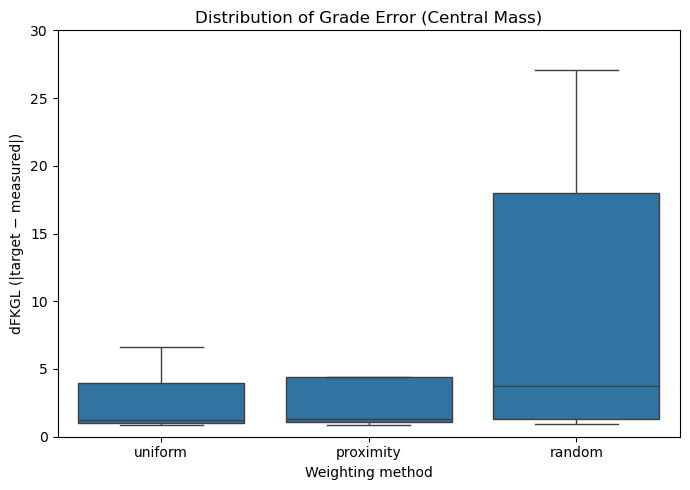

In [26]:


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="weight_method",
    y="dfkgl",
    showfliers=False  # hide extreme outliers; we show them elsewhere
)

plt.ylim(0, 30)  # focus on pedagogically meaningful range
plt.ylabel("dFKGL (|target − measured|)")
plt.xlabel("Weighting method")
plt.title("Distribution of Grade Error (Central Mass)")

plt.tight_layout()
plt.show()



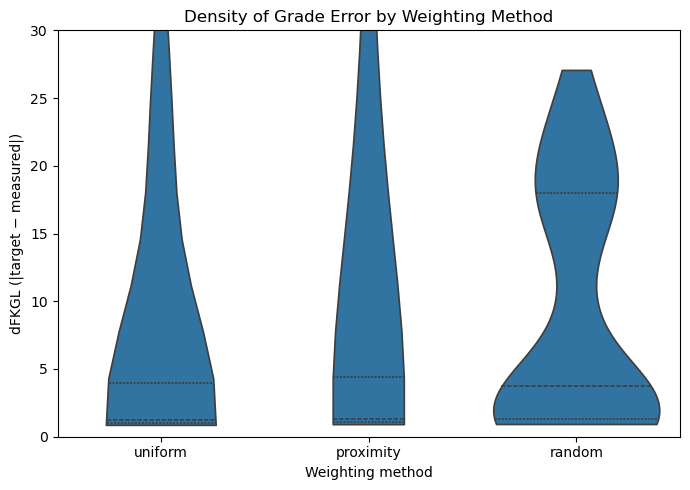

In [27]:
plt.figure(figsize=(7, 5))

sns.violinplot(
    data=df,
    x="weight_method",
    y="dfkgl",
    inner="quartile",
    cut=0
)

plt.ylim(0, 30)
plt.ylabel("dFKGL (|target − measured|)")
plt.xlabel("Weighting method")
plt.title("Density of Grade Error by Weighting Method")

plt.tight_layout()
plt.show()


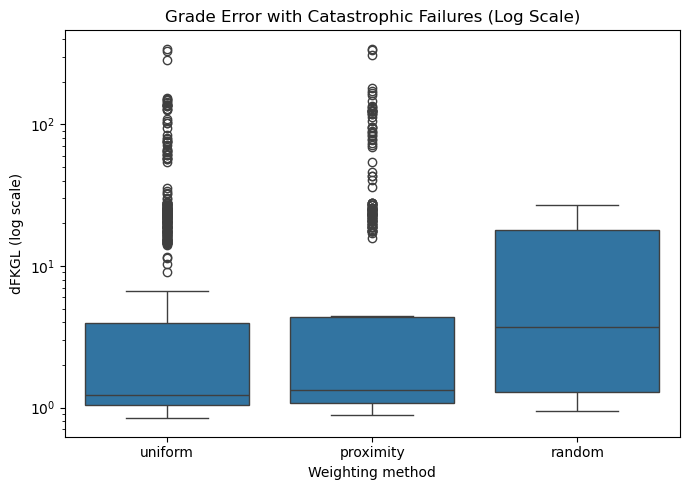

In [28]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="weight_method",
    y="dfkgl"
)

plt.yscale("log")
plt.ylabel("dFKGL (log scale)")
plt.xlabel("Weighting method")
plt.title("Grade Error with Catastrophic Failures (Log Scale)")

plt.tight_layout()
plt.show()


In [29]:
merge_summary = (
    df.groupby("merge_method", as_index=False)
      .agg(
          median_dfkgl=("dfkgl", "median"),
          mean_dfkgl=("dfkgl", "mean"),
          max_dfkgl=("dfkgl", "max"),
          n=("dfkgl", "size")
      )
)

merge_summary


,merge_method,median_dfkgl,mean_dfkgl,max_dfkgl,n
0,dareties,1.189941,3.925173,75.102734,1166
1,linear,25.478516,56.471855,341.087500,220


In [30]:
df_dare = df[df["merge_method"] != "linear"].copy()
weighting_summary_dare = (
    df_dare.groupby("weight_method", as_index=False)
           .agg(
               median_dfkgl=("dfkgl", "median"),
               mean_dfkgl=("dfkgl", "mean"),
               n=("dfkgl", "size")
           )
           .sort_values("median_dfkgl")
)

weighting_summary_dare


,weight_method,median_dfkgl,mean_dfkgl,n
2,uniform,1.155273,4.288567,737
0,proximity,1.186035,1.554325,330
1,random,3.708789,9.122727,99


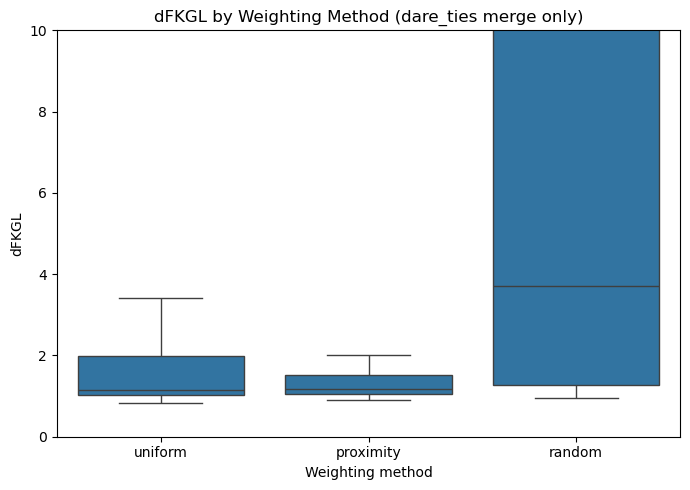

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
sns.boxplot(data=df_dare, x="weight_method", y="dfkgl", showfliers=False)
plt.ylim(0, 10)
plt.title("dFKGL by Weighting Method (dare_ties merge only)")
plt.ylabel("dFKGL")
plt.xlabel("Weighting method")
plt.tight_layout()
plt.show()


In [32]:
df = results.copy()
df_valid = df[df["merge_method"] != "linear"].copy()

avg_weight_diagnostics = (
    df_valid.groupby("weight_average", as_index=False)
            .agg(
                median_dfkgl=("dfkgl", "median"),
                mean_dfkgl=("dfkgl", "mean"),
                median_sari=("sari", "median"),
                mean_sari=("sari", "mean"),
                n=("dfkgl", "size")
            )
            .sort_values("weight_average")
)

avg_weight_diagnostics


,weight_average,median_dfkgl,mean_dfkgl,median_sari,mean_sari,n
0,0.00,1.110352,1.859079,74.744111,62.360660,33
1,0.09,3.247461,3.336552,34.253757,34.529370,110
2,0.50,1.984766,2.089915,51.528217,49.470385,55
3,1.00,1.079297,2.121035,75.464621,72.849620,781
4,2.00,15.484570,13.823526,34.743932,43.316752,55
5,3.00,20.095508,27.815614,33.382521,34.890302,55


In [33]:
avg_weight_primary = (
    df_valid.groupby("weight_average", as_index=False)
            .agg(
                median_dfkgl=("dfkgl", "median"),
                mean_dfkgl=("dfkgl", "mean"),
                n=("dfkgl", "size")
            )
            .sort_values("median_dfkgl")
)

avg_weight_primary


,weight_average,median_dfkgl,mean_dfkgl,n
3,1.00,1.079297,2.121035,781
0,0.00,1.110352,1.859079,33
2,0.50,1.984766,2.089915,55
1,0.09,3.247461,3.336552,110
4,2.00,15.484570,13.823526,55
5,3.00,20.095508,27.815614,55


In [34]:
method_weight_interaction = (
    df_valid.groupby(["weight_method", "weight_average"], as_index=False)
            .agg(
                median_dfkgl=("dfkgl", "median"),
                mean_dfkgl=("dfkgl", "mean"),
                median_sari=("sari", "median"),
                n=("dfkgl", "size")
            )
            .sort_values(["weight_average", "median_dfkgl"])
)

method_weight_interaction


,weight_method,weight_average,median_dfkgl,mean_dfkgl,median_sari,n
3,uniform,0.09,3.221875,3.322955,34.223636,55
0,proximity,0.09,3.271680,3.350149,34.283878,55
4,uniform,0.50,1.984766,2.089915,51.528217,55
5,uniform,1.00,1.056836,1.107957,75.625476,517
1,proximity,1.00,1.066797,1.094332,76.147445,165
2,random,1.00,3.708789,9.122727,68.877073,99
6,uniform,2.00,15.484570,13.823526,34.743932,55
7,uniform,3.00,20.095508,27.815614,33.382521,55


In [35]:
df_aw1 = df_valid[df_valid["weight_average"] == 1].copy()

weighting_primary_aw1 = (
    df_aw1.groupby("weight_method", as_index=False)
          .agg(
              median_dfkgl=("dfkgl", "median"),
              mean_dfkgl=("dfkgl", "mean"),
              n=("dfkgl", "size")
          )
          .sort_values("median_dfkgl")
)

weighting_primary_aw1


,weight_method,median_dfkgl,mean_dfkgl,n
2,uniform,1.056836,1.107957,517
0,proximity,1.066797,1.094332,165
1,random,3.708789,9.122727,99


In [36]:
df_final = results[
    (df["merge_method"] == "dareties") &
    (df["weight_average"] == 1) &
    (df["weight_method"].isin(["uniform", "proximity"]))
].copy()

grade_means = (
    df_final.groupby(["grade", "weight_method"], as_index=False)
            .agg(mean_dfkgl=("dfkgl", "mean"))
)
grade_pivot = grade_means.pivot(
    index="grade",
    columns="weight_method",
    values="mean_dfkgl"
).reset_index()
grade_pivot["winner"] = grade_pivot.apply(
    lambda row: "uniform"
    if row["uniform"] < row["proximity"]
    else "proximity",
    axis=1
)


grade_pivot

weight_method,grade,proximity,uniform,winner
0,2,1.060352,1.056869,uniform
1,3,1.055990,1.062005,proximity
2,4,1.038424,1.053807,proximity
3,5,1.013437,1.019224,proximity
4,6,0.930833,0.927930,uniform
5,7,1.126602,1.196937,proximity
6,8,1.014622,1.032692,proximity
7,9,1.077435,1.085451,proximity
8,10,1.299922,1.308357,proximity
9,11,1.176719,1.243887,proximity


In [37]:
grade_medians = (
    df_final.groupby(["grade", "weight_method"], as_index=False)
            .agg(median_dfkgl=("dfkgl", "median"))
)

grade_pivot_med = grade_medians.pivot(
    index="grade",
    columns="weight_method",
    values="median_dfkgl"
).reset_index()

grade_pivot_med["winner"] = grade_pivot_med.apply(
    lambda row: "uniform"
    if row["uniform"] < row["proximity"]
    else "proximity",
    axis=1
)

grade_pivot_med

weight_method,grade,proximity,uniform,winner
0,2,1.010156,0.984375,uniform
1,3,1.051367,1.040625,uniform
2,4,1.033789,1.028906,uniform
3,5,1.000000,1.000781,proximity
4,6,0.920508,0.907227,uniform
5,7,1.141797,1.147852,proximity
6,8,0.992578,1.006836,proximity
7,9,1.073828,1.060742,uniform
8,10,1.305273,1.305273,proximity
9,11,1.209766,1.229883,proximity


In [38]:
df_cmp = results[
    (df["merge_method"] == "dareties") &
    (df["weight_average"] == 1) &
    (df["weight_method"].isin(["uniform", "proximity"]))
].copy()

import numpy as np

def prob_uniform_better(u, p):
    u = np.asarray(u)
    p = np.asarray(p)
    return (u[:, None] < p[None, :]).mean()


In [39]:
grade_results = []

for grade, gdf in df_cmp.groupby("grade"):
    u = gdf.loc[gdf["weight_method"] == "uniform", "dfkgl"]
    p = gdf.loc[gdf["weight_method"] == "proximity", "dfkgl"]
    
    if len(u) == 0 or len(p) == 0:
        continue
    
    prob_u_wins = prob_uniform_better(u, p)
    
    grade_results.append({
        "grade": grade,
        "n_uniform": len(u),
        "n_proximity": len(p),
        "P(uniform < proximity)": prob_u_wins,
        "winner": (
            "uniform" if prob_u_wins > 0.5
            else "proximity" if prob_u_wins < 0.5
            else "tie"
        )
    })

grade_dominance = pd.DataFrame(grade_results)
grade_dominance


,grade,n_uniform,n_proximity,P(uniform < proximity),winner
0,2,47,15,0.605674,uniform
1,3,47,15,0.580142,uniform
2,4,47,15,0.495035,proximity
3,5,47,15,0.529078,uniform
4,6,47,15,0.612766,uniform
5,7,47,15,0.364539,proximity
6,8,47,15,0.489362,proximity
7,9,47,15,0.506383,uniform
8,10,47,15,0.507801,uniform
9,11,47,15,0.339007,proximity


In [40]:
df_cmp.groupby(["grade", "weight_method"]).size().unstack(fill_value=0)


weight_method,proximity,uniform
grade,,
2,15,47
3,15,47
4,15,47
5,15,47
6,15,47
7,15,47
8,15,47
9,15,47
10,15,47


In [41]:
results['run_name'].unique()

array(['off-the-shelf-baseline', 'shared-warmup',
       'graded-from-shared-warmup',
       'dareties_g@all_ws@all_w@uniform_average',
       'dareties_ws@4_w@uniform_average',
       'dareties_ws@2_w@proximity_average',
       'dareties_ws@3_w@uniform_average',
       'dareties_ws@4_w@proximity_average',
       'dareties_ws@2_w@uniform_average',
       'dareties_ws@3_w@proximity_average',
       'dareties_ws@1_w@uniform_average',
       'dareties_ws@5_w@proximity_average',
       'dareties_ws@5_w@uniform_average', 'graded-from-off-the-shelf',
       'dareties_ws@3_w@proximity_sum', 'dareties_ws@3_w@uniform_sum',
       'dareties_ws@4_w@proximity_sum', 'dareties_ws@4_w@uniform_sum',
       'dareties_ws@2_w@proximity_sum', 'dareties_ws@5_w@proximity_sum',
       'dareties_ws@5_w@uniform_sum',
       'ots_dareties_ws@3_w@proximity_average',
       'ots_dareties_ws@4_w@proximity_average',
       'ots_dareties_ws@4_w@uniform_average',
       'ots_dareties_ws@3_w@uniform_average',
       '

In [89]:
# average results by run_name

avging = results.copy()

avg_results = avging.groupby('run_name').agg(
    mean_dfkgl=('dfkgl', 'mean'),
    mean_sari=('sari', 'mean'),
    mean_bertscore=('bertF1', 'mean')
).reset_index()

for row in avg_results.itertuples():
    print(f"dfkgl: {round(row.mean_dfkgl, 2)},\t  sari: {round(row.mean_sari, 2)},\t bert: {round(row.mean_bertscore, 2)},\t {row.run_name}")

dfkgl: 1.12,	  sari: 76.31,	 bert: 95.9,	 dareties_g@all_ws@all_w@uniform_average
dfkgl: 1.04,	  sari: 76.43,	 bert: 95.88,	 dareties_ws@1-copies_w@uniform_average
dfkgl: 1.04,	  sari: 76.46,	 bert: 95.87,	 dareties_ws@10-copies_w@uniform_average
dfkgl: 1.15,	  sari: 75.13,	 bert: 95.69,	 dareties_ws@10_w@random-1_average
dfkgl: 4.64,	  sari: 67.02,	 bert: 83.39,	 dareties_ws@10_w@random-2_average
dfkgl: 20.04,	  sari: 25.26,	 bert: 15.49,	 dareties_ws@10_w@random-3_average
dfkgl: 1.04,	  sari: 76.53,	 bert: 95.86,	 dareties_ws@11-copies_w@uniform_average
dfkgl: 1.16,	  sari: 75.34,	 bert: 95.73,	 dareties_ws@11_w@random-1_average
dfkgl: 5.63,	  sari: 64.52,	 bert: 79.04,	 dareties_ws@11_w@random-2_average
dfkgl: 20.79,	  sari: 24.12,	 bert: 13.5,	 dareties_ws@11_w@random-3_average
dfkgl: 1.2,	  sari: 74.37,	 bert: 95.74,	 dareties_ws@12_w@random-1_average
dfkgl: 7.62,	  sari: 59.24,	 bert: 70.39,	 dareties_ws@12_w@random-2_average
dfkgl: 19.86,	  sari: 26.57,	 bert: 18.38,	 dareties_w

In [42]:
import re
use_results = results.copy()
df_final = use_results[
    (df["merge_method"] == "dareties") &
    (df["weight_average"] == 1) &
    (df["weight_method"].isin(["uniform", "proximity"])) &
    (df["window_size"].isin(set(range(1,6)))) & 
    (results['run_name'].str.contains("proximity_average") | results['run_name'].str.contains("uniform_average"))
     
].copy()

def parse_run_name(run_name):
    return {
        "is_ots": run_name.startswith("ots_"),
        "window_size_from_name": int(re.search(r"ws@(\d+)", run_name).group(1)),
        "weight_method_from_name": re.search(r"w@([a-z]+)_average", run_name).group(1)
    }


parsed = df_final["run_name"].apply(parse_run_name)
parsed = parsed.apply(pd.Series)
df_final = pd.concat([df_final, parsed], axis=1)
df_final['run_name'].unique()


array(['dareties_ws@4_w@uniform_average',
       'dareties_ws@2_w@proximity_average',
       'dareties_ws@3_w@uniform_average',
       'dareties_ws@4_w@proximity_average',
       'dareties_ws@2_w@uniform_average',
       'dareties_ws@3_w@proximity_average',
       'dareties_ws@1_w@uniform_average',
       'dareties_ws@5_w@proximity_average',
       'dareties_ws@5_w@uniform_average',
       'ots_dareties_ws@3_w@proximity_average',
       'ots_dareties_ws@4_w@proximity_average',
       'ots_dareties_ws@4_w@uniform_average',
       'ots_dareties_ws@3_w@uniform_average',
       'ots_dareties_ws@2_w@uniform_average',
       'ots_dareties_ws@2_w@proximity_average',
       'ots_dareties_ws@1_w@uniform_average',
       'ots_dareties_ws@1_w@proximity_average',
       'ots_dareties_ws@5_w@uniform_average',
       'ots_dareties_ws@5_w@proximity_average',
       'dareties_ws@1_w@proximity_average',
       'dareties_ws@3-copies_w@uniform_average',
       'dareties_ws@5-copies_w@uniform_average',
  

   n_adapters  mean_dfkgl  median_dfkgl  n_runs
0           2    1.710742      1.465137       8
1           3    1.123714      1.118164      55
2           4    1.067847      1.072070      16
3           5    1.061456      1.051172      55
4           6    1.117619      1.104102      24
5           7    1.066448      1.040625      47
6           8    1.103040      1.062695      16
7           9    1.033493      1.032031      31
8          10    0.972266      0.965332       8
9          11    1.054219      1.060352      15


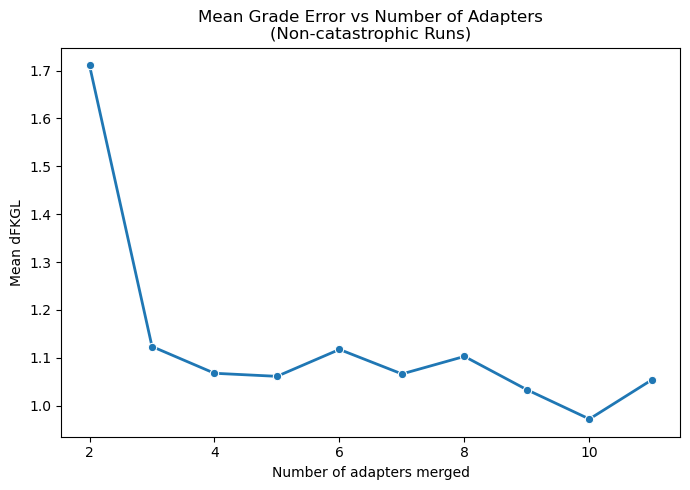

In [43]:
mean_by_adapters = (
    df_final.groupby("n_adapters", as_index=False)
         .agg(
             mean_dfkgl=("dfkgl", "mean"),
             median_dfkgl=("dfkgl", "median"),
             n_runs=("dfkgl", "size")
         )
         .sort_values("n_adapters")
)

print(mean_by_adapters)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

sns.lineplot(
    data=mean_by_adapters,
    x="n_adapters",
    y="mean_dfkgl",
    marker="o",
    linewidth=2
)

plt.xlabel("Number of adapters merged")
plt.ylabel("Mean dFKGL")
plt.title("Mean Grade Error vs Number of Adapters\n(Non-catastrophic Runs)")

plt.tight_layout()
plt.show()


In [44]:
df_final['window_size'].value_counts()

window_size
4.0    55
2.0    55
3.0    55
1.0    55
5.0    55
Name: count, dtype: int64

In [45]:
import numpy as np

def prob_uniform_better(u, p):
    u = np.asarray(u)
    p = np.asarray(p)
    return (u[:, None] < p[None, :]).mean()

def dominance_within_group(df_group):
    rows = []
    for (ws, grade), gdf in df_group.groupby(["window_size", "grade"]):
        u = gdf.loc[gdf["weight_method"] == "uniform", "dfkgl"]
        p = gdf.loc[gdf["weight_method"] == "proximity", "dfkgl"]
        
        if len(u) == 0 or len(p) == 0:
            continue
        
        rows.append({
            "window_size": ws,
            "grade": grade,
            "n_uniform": len(u),
            "n_proximity": len(p),
            "P(uniform < proximity)": prob_uniform_better(u, p),
            "winner": (
                "uniform" if prob_uniform_better(u, p) > 0.5
                else "proximity"
            )
        })
    return pd.DataFrame(rows)



In [46]:
ots_results = dominance_within_group(df_final[df_final["is_ots"]])
ots_results



,window_size,grade,n_uniform,n_proximity,P(uniform < proximity),winner
0,1.0,2,1,1,0.0,proximity
1,1.0,3,1,1,1.0,uniform
2,1.0,4,1,1,1.0,uniform
3,1.0,5,1,1,1.0,uniform
4,1.0,6,1,1,1.0,uniform
5,1.0,7,1,1,1.0,uniform
6,1.0,8,1,1,1.0,uniform
7,1.0,9,1,1,0.0,proximity
8,1.0,10,1,1,1.0,uniform
9,1.0,11,1,1,0.0,proximity


In [47]:
ots_results["winner"].value_counts()

winner
proximity    29
uniform      26
Name: count, dtype: int64

In [48]:

ots_results["P(uniform < proximity)"].mean()

np.float64(0.4727272727272727)

In [49]:
non_ots_results = dominance_within_group(df_final[~df_final["is_ots"]])
non_ots_results


,window_size,grade,n_uniform,n_proximity,P(uniform < proximity),winner
0,1.0,2,2,1,0.5,proximity
1,1.0,3,2,1,0.0,proximity
2,1.0,4,2,1,0.5,proximity
3,1.0,5,2,1,1.0,uniform
4,1.0,6,2,1,0.5,proximity
5,1.0,7,2,1,0.5,proximity
6,1.0,8,2,1,1.0,uniform
7,1.0,9,2,1,0.5,proximity
8,1.0,10,2,1,1.0,uniform
9,1.0,11,2,1,0.5,proximity


In [50]:
non_ots_results["winner"].value_counts()

winner
proximity    30
uniform      25
Name: count, dtype: int64

In [51]:
non_ots_results["P(uniform < proximity)"].mean()

np.float64(0.6272727272727273)

In [52]:
ots_dfkgl = df_final.loc[df_final["is_ots"], "dfkgl"]
non_ots_dfkgl = df_final.loc[~df_final["is_ots"], "dfkgl"]

prob_ots_better = (ots_dfkgl.values[:, None] < non_ots_dfkgl.values[None, :]).mean()
prob_ots_better


np.float64(0.44831955922865013)

In [53]:
ots_vs_non_by_method = (
    df_final.groupby(["is_ots", "weight_method"])
            .agg(median_dfkgl=("dfkgl", "median"),
                 mean_dfkgl=("dfkgl", "mean"),
                 n=("dfkgl", "size"))
            .reset_index()
)

ots_vs_non_by_method


,is_ots,weight_method,median_dfkgl,mean_dfkgl,n
0,False,proximity,1.066797,1.096509,55
1,False,uniform,1.049023,1.091570,110
2,True,proximity,1.073438,1.096264,55
3,True,uniform,1.062891,1.100089,55


In [54]:
results_with_adapter_numbers = results.copy()

print(results_with_adapter_numbers['n_adapters'].value_counts())

n_adapters
5     242
3     242
7     200
11    142
6     137
9     116
8      95
4      95
1      55
2      53
10     53
Name: count, dtype: int64


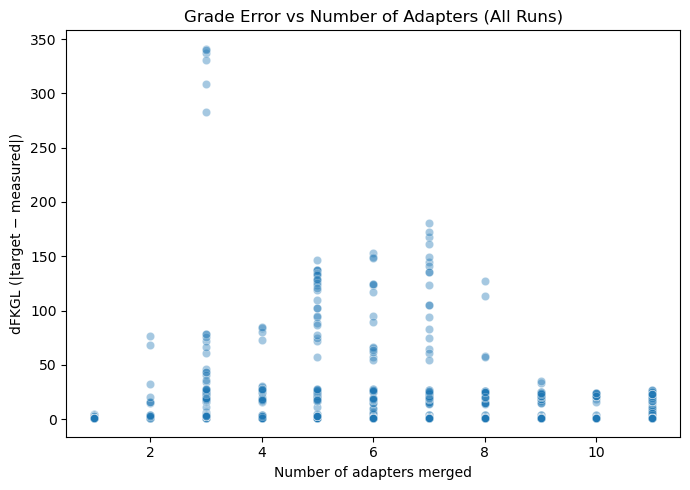

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt
df = results_with_adapter_numbers.copy()
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="n_adapters",
    y="dfkgl",
    alpha=0.4
)

plt.xlabel("Number of adapters merged")
plt.ylabel("dFKGL (|target − measured|)")
plt.title("Grade Error vs Number of Adapters (All Runs)")

plt.tight_layout()
plt.show()


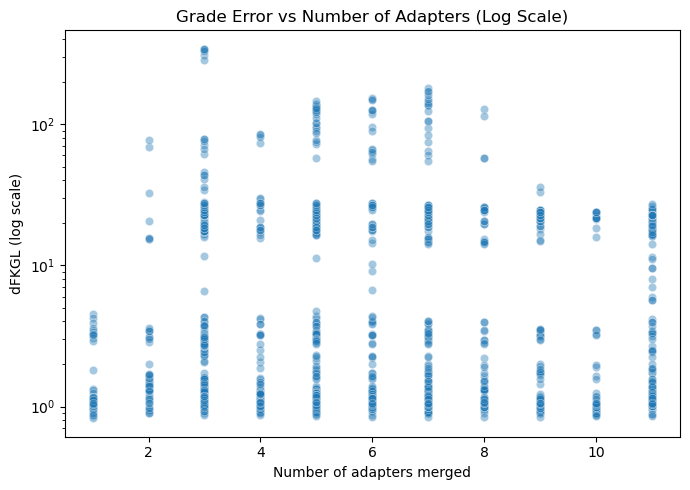

In [56]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="n_adapters",
    y="dfkgl",
    alpha=0.4
)

plt.yscale("log")
plt.xlabel("Number of adapters merged")
plt.ylabel("dFKGL (log scale)")
plt.title("Grade Error vs Number of Adapters (Log Scale)")

plt.tight_layout()
plt.show()


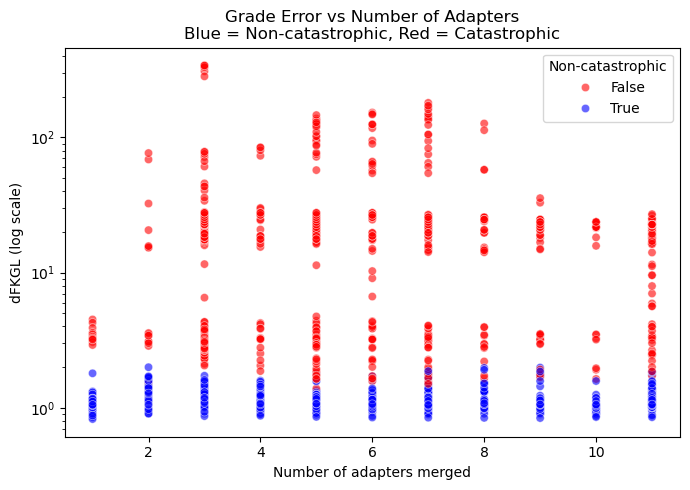

In [57]:
plt.figure(figsize=(7, 5))
df["non_catastrophic"] = (df["dfkgl"] <= 2) & (df["sari"] >= 55)

sns.scatterplot(
    data=df,
    x="n_adapters",
    y="dfkgl",
    hue="non_catastrophic",
    palette={True: "blue", False: "red"},
    alpha=0.6
)

plt.yscale("log")
plt.xlabel("Number of adapters merged")
plt.ylabel("dFKGL (log scale)")
plt.title("Grade Error vs Number of Adapters\nBlue = Non-catastrophic, Red = Catastrophic")

plt.legend(title="Non-catastrophic")
plt.tight_layout()
plt.show()


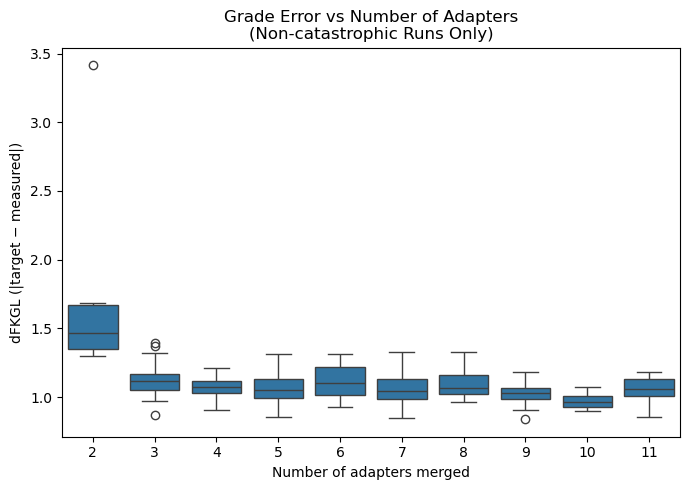

In [58]:
df_nc = df[df["non_catastrophic"]].copy()
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

# scatter
sns.boxplot(
    data=df_final,
    x="n_adapters",
    y="dfkgl",
)

# median trendline

plt.xlabel("Number of adapters merged")
plt.ylabel("dFKGL (|target − measured|)")
plt.title("Grade Error vs Number of Adapters\n(Non-catastrophic Runs Only)")

plt.tight_layout()
plt.show()


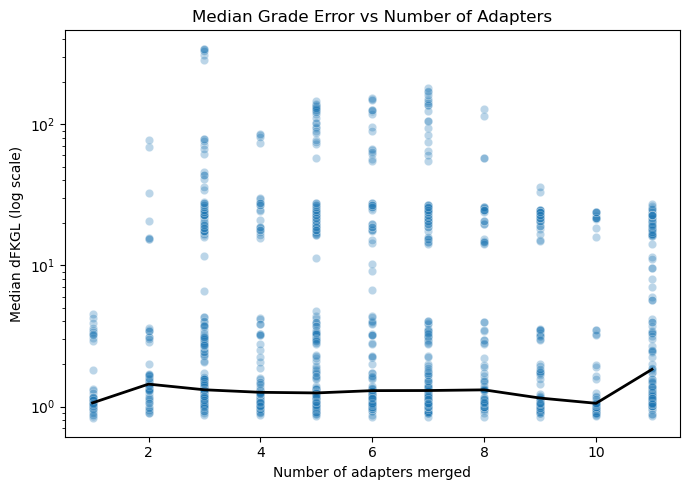

In [59]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="n_adapters",
    y="dfkgl",
    alpha=0.3
)

sns.lineplot(
    data=df,
    x="n_adapters",
    y="dfkgl",
    estimator="median",
    errorbar=None,
    color="black",
    linewidth=2
)

plt.yscale("log")
plt.xlabel("Number of adapters merged")
plt.ylabel("Median dFKGL (log scale)")
plt.title("Median Grade Error vs Number of Adapters")

plt.tight_layout()
plt.show()


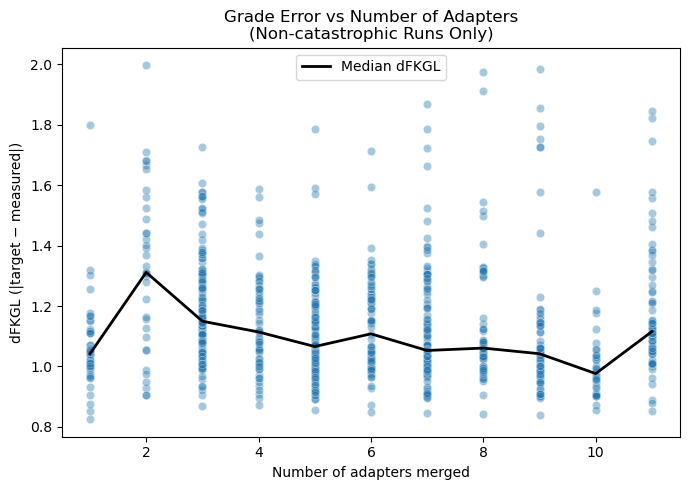

In [60]:
df_nc = df[df["non_catastrophic"]].copy()
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

# scatter
sns.scatterplot(
    data=df_nc,
    x="n_adapters",
    y="dfkgl",
    alpha=0.4
)

# median trendline
sns.lineplot(
    data=df_nc,
    x="n_adapters",
    y="dfkgl",
    estimator="median",
    errorbar=None,
    color="black",
    linewidth=2,
    label="Median dFKGL"
)

plt.xlabel("Number of adapters merged")
plt.ylabel("dFKGL (|target − measured|)")
plt.title("Grade Error vs Number of Adapters\n(Non-catastrophic Runs Only)")

plt.tight_layout()
plt.show()


In [61]:

mean_by_adapters = (
    df_nc.groupby("n_adapters", as_index=False)
         .agg(
             mean_dfkgl=("dfkgl", "mean"),
             median_dfkgl=("dfkgl", "median"),
             n_runs=("dfkgl", "size")
         )
         .sort_values("n_adapters")
)

mean_by_adapters


,n_adapters,mean_dfkgl,median_dfkgl,n_runs
0,1,1.067205,1.041895,44
1,2,1.325463,1.311719,35
2,3,1.185491,1.149805,148
3,4,1.142370,1.114160,60
4,5,1.099557,1.066016,142
5,6,1.133623,1.108008,81
6,7,1.117773,1.052930,119
7,8,1.140856,1.060938,60
8,9,1.107055,1.042188,73
9,10,1.009335,0.976465,34


In [62]:
all_adapters = df_nc[df_nc['n_adapters'] == 11]
print(all_adapters['run_name'].value_counts())

run_name
dareties_g@all_ws@all_w@uniform_average      11
dareties_ws@11-copies_w@uniform_average      11
dareties_ws@10_w@random-1_average            11
dareties_ws@12_w@random-1_average            11
dareties_ws@11_w@random-1_average            11
dareties_ws@11_w@random-2_average             3
dareties_ws@5_w@proximity_average             1
dareties_ws@5_w@uniform_average               1
ots_dareties_ws@5_w@uniform_average           1
dareties_ws@5_w@uniform_no-tgt-grade          1
ots_dareties_ws@5_w@proximity_average         1
dareties_ws@5_w@uniform_upshifted-2           1
dareties_ws@5_w@uniform_upshifted-1           1
dareties_ws@5_w@uniform_downshifted-2         1
dareties_ws@5_w@uniform_downshifted-1         1
dareties_ws@12_w@random-2_average             1
dareties_ws@10_w@random-2_average             1
dareties_ws@5_w@proximity-flatter_average     1
dareties_ws@5_w@proximity-squared_average     1
Name: count, dtype: int64


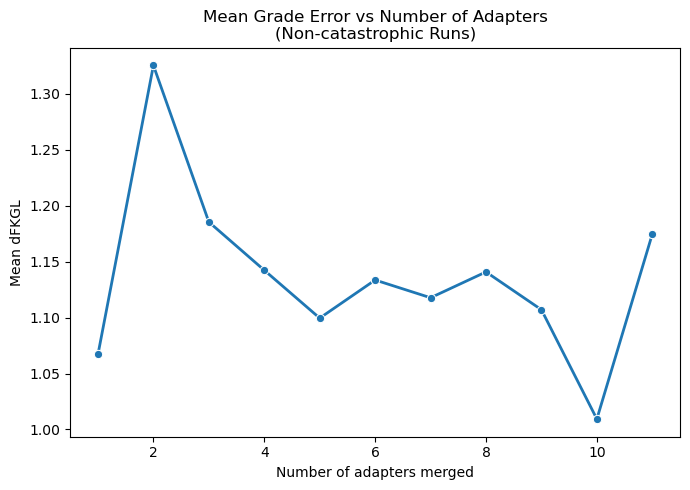

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

sns.lineplot(
    data=mean_by_adapters,
    x="n_adapters",
    y="mean_dfkgl",
    marker="o",
    linewidth=2
)

plt.xlabel("Number of adapters merged")
plt.ylabel("Mean dFKGL")
plt.title("Mean Grade Error vs Number of Adapters\n(Non-catastrophic Runs)")

plt.tight_layout()
plt.show()


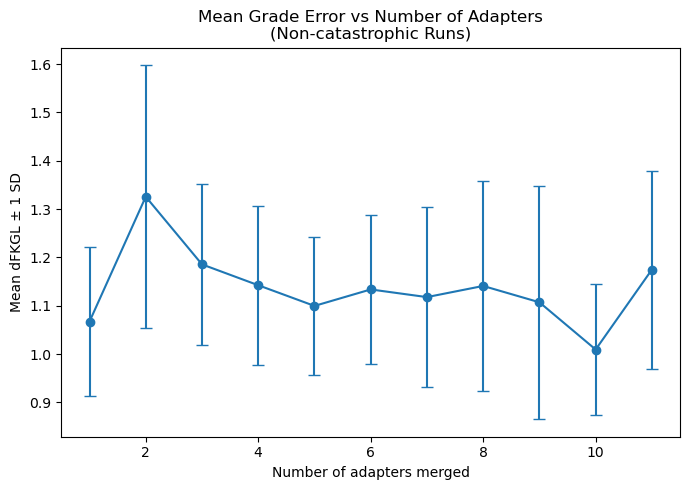

In [64]:
std_by_adapters = (
    df_nc.groupby("n_adapters")["dfkgl"]
         .std()
         .reset_index(name="std_dfkgl")
)

mean_by_adapters = mean_by_adapters.merge(std_by_adapters, on="n_adapters")

plt.figure(figsize=(7, 5))

plt.errorbar(
    mean_by_adapters["n_adapters"],
    mean_by_adapters["mean_dfkgl"],
    yerr=mean_by_adapters["std_dfkgl"],
    fmt="o-",
    capsize=4
)

plt.xlabel("Number of adapters merged")
plt.ylabel("Mean dFKGL ± 1 SD")
plt.title("Mean Grade Error vs Number of Adapters\n(Non-catastrophic Runs)")

plt.tight_layout()
plt.show()


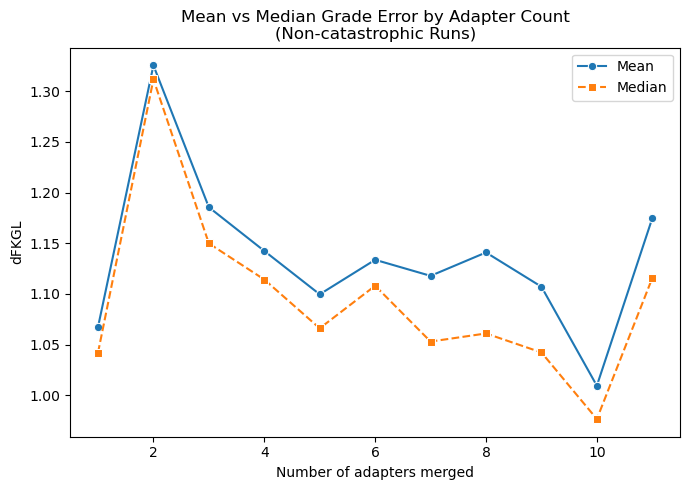

In [65]:
plt.figure(figsize=(7, 5))

sns.lineplot(
    data=mean_by_adapters,
    x="n_adapters",
    y="mean_dfkgl",
    marker="o",
    label="Mean"
)

sns.lineplot(
    data=mean_by_adapters,
    x="n_adapters",
    y="median_dfkgl",
    marker="s",
    linestyle="--",
    label="Median"
)

plt.xlabel("Number of adapters merged")
plt.ylabel("dFKGL")
plt.title("Mean vs Median Grade Error by Adapter Count\n(Non-catastrophic Runs)")
plt.legend()

plt.tight_layout()
plt.show()


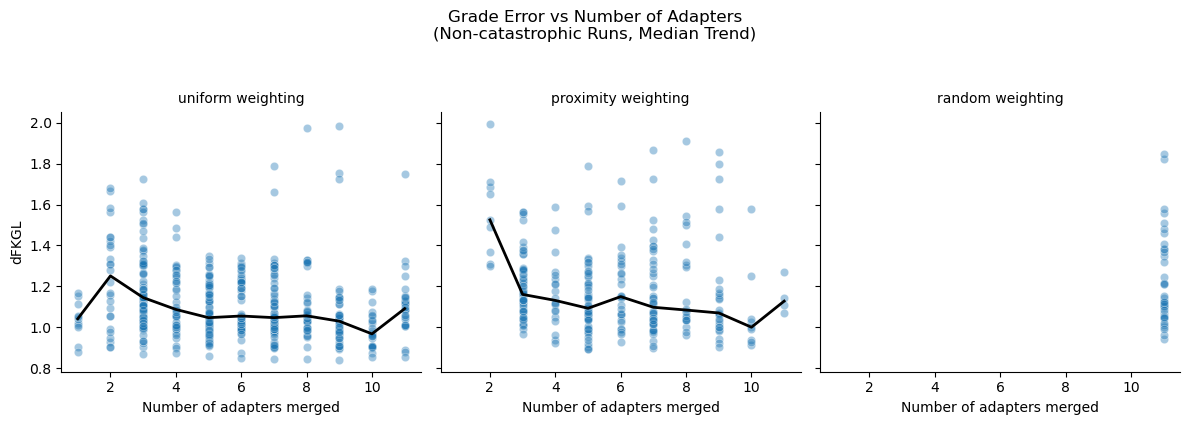

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(
    df_nc,
    col="weight_method",
    height=4,
    aspect=1,
    sharey=True
)

# scatter points
g.map_dataframe(
    sns.scatterplot,
    x="n_adapters",
    y="dfkgl",
    alpha=0.4
)

# median trendline
g.map_dataframe(
    sns.lineplot,
    x="n_adapters",
    y="dfkgl",
    estimator="median",
    errorbar=None,
    color="black",
    linewidth=2
)

g.set_axis_labels("Number of adapters merged", "dFKGL")
g.set_titles(col_template="{col_name} weighting")
g.fig.suptitle(
    "Grade Error vs Number of Adapters\n(Non-catastrophic Runs, Median Trend)",
    y=1.05
)

plt.tight_layout()
plt.show()


  weight_method  n_adapters  mean_dfkgl  median_dfkgl  n_runs
0     proximity           2    1.454492      1.416797       4
1     proximity           3    1.132946      1.133398      22
2     proximity           4    1.080615      1.098633       8
3     proximity           5    1.065421      1.062988      22
4     proximity           6    1.111735      1.104102      12


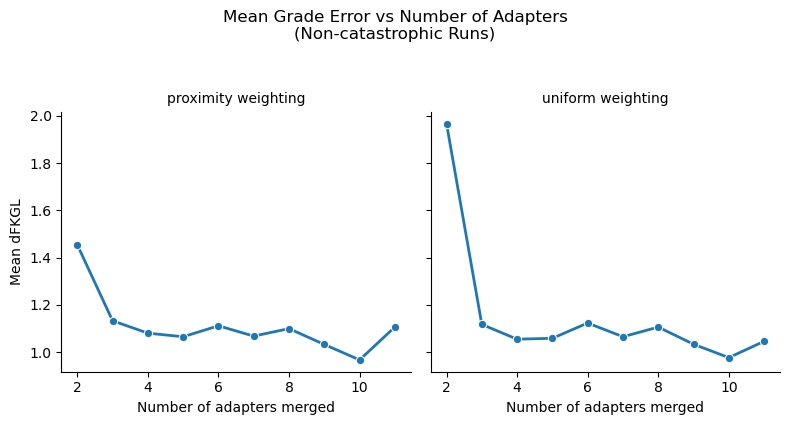

In [67]:
mean_by_adapters_method = (
    df_final.groupby(["weight_method", "n_adapters"], as_index=False)
         .agg(
             mean_dfkgl=("dfkgl", "mean"),
             median_dfkgl=("dfkgl", "median"),
             n_runs=("dfkgl", "size")
         )
)

print(mean_by_adapters_method.head())

g = sns.FacetGrid(
    mean_by_adapters_method,
    col="weight_method",
    height=4,
    aspect=1,
    sharey=True
)

g.map_dataframe(
    sns.lineplot,
    x="n_adapters",
    y="mean_dfkgl",
    marker="o",
    linewidth=2
)

g.set_axis_labels("Number of adapters merged", "Mean dFKGL")
g.set_titles(col_template="{col_name} weighting")
g.fig.suptitle(
    "Mean Grade Error vs Number of Adapters\n(Non-catastrophic Runs)",
    y=1.05
)

plt.tight_layout()
plt.show()


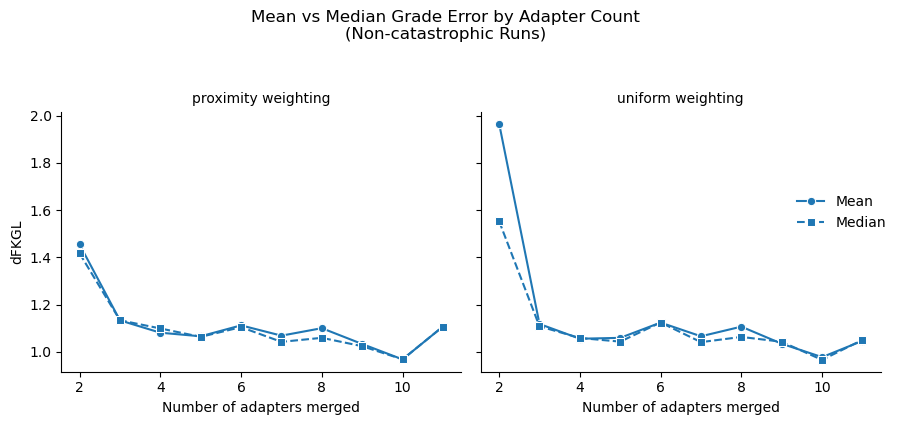

In [68]:
g = sns.FacetGrid(
    mean_by_adapters_method,
    col="weight_method",
    height=4,
    aspect=1,
    sharey=True
)

g.map_dataframe(
    sns.lineplot,
    x="n_adapters",
    y="mean_dfkgl",
    marker="o",
    label="Mean"
)

g.map_dataframe(
    sns.lineplot,
    x="n_adapters",
    y="median_dfkgl",
    marker="s",
    linestyle="--",
    label="Median"
)

g.add_legend()
g.set_axis_labels("Number of adapters merged", "dFKGL")
g.set_titles(col_template="{col_name} weighting")
g.fig.suptitle(
    "Mean vs Median Grade Error by Adapter Count\n(Non-catastrophic Runs)",
    y=1.05
)

plt.tight_layout()
plt.show()


In [ ]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def _chunk(lst, chunk_size):
    for i in range(0, len(lst), chunk_size):
        yield lst[i:i + chunk_size]


import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def _chunk(lst, chunk_size):
    for i in range(0, len(lst), chunk_size):
        yield lst[i:i + chunk_size]


def plot_schemes_scatter_n_adapters(
    df: pd.DataFrame,
    weight_schemes,
    scheme_col: str = "weight_scheme",
    y_col: str = "dfkgl",
    x_col: str = "n_adapters",
    ncols: int = 4,
    plots_per_fig: int = 12,
    only_non_catastrophic: bool = False,
    non_catastrophic_col: str = "non_catastrophic",
    y_log: bool = False,
    alpha: float = 0.35,
    add_mean_line: bool = True,
    trend_min_points: int = 2,
    median_kwargs: dict | None = None,
    mean_kwargs: dict | None = None,
):
    """
    For each weight_scheme: scatter n_adapters vs dfkgl + trendline(s) by n_adapters.
      - Always plots median trendline (black).
      - Optionally plots mean trendline (red).
    Creates multiple figures if you have many schemes.

    Notes:
      - trend lines are computed as aggregation per x_col within each scheme.
      - trend_min_points prevents plotting if there are too few unique x values.
    """
    median_kwargs = median_kwargs or {"color": "black", "linewidth": 2, "linestyle": "-"}
    mean_kwargs = mean_kwargs or {"color": "red", "linewidth": 2, "linestyle": "--"}

    if only_non_catastrophic:
        if non_catastrophic_col not in df.columns:
            raise ValueError(f"Expected column '{non_catastrophic_col}' when only_non_catastrophic=True.")
        plot_df = df[df[non_catastrophic_col]].copy()
    else:
        plot_df = df.copy()

    # Keep only schemes requested AND present
    present = set(plot_df[scheme_col].dropna().unique())
    schemes = [s for s in weight_schemes if s in present]
    missing = [s for s in weight_schemes if s not in present]
    if missing:
        print(f"Note: {len(missing)} schemes not found in '{scheme_col}' and will be skipped.")

    if not schemes:
        raise ValueError("No schemes found to plot after filtering. Check scheme_col and weight_schemes values.")

    sns.set_style("whitegrid")

    for page_idx, schemes_page in enumerate(_chunk(schemes, plots_per_fig), start=1):
        nplots = len(schemes_page)
        nrows = math.ceil(nplots / ncols)

        fig, axes = plt.subplots(
            nrows=nrows,
            ncols=ncols,
            figsize=(4.2 * ncols, 3.6 * nrows),
            sharex=False,
            sharey=False
        )
        axes = np.array(axes).reshape(-1)

        for ax_i, scheme in enumerate(schemes_page):
            ax = axes[ax_i]
            sdf = plot_df[plot_df[scheme_col] == scheme]

            # Scatter
            sns.scatterplot(
                data=sdf,
                x=x_col,
                y=y_col,
                alpha=alpha,
                ax=ax,
                edgecolor=None
            )

            # Build trend table: median and mean per n_adapters
            trend = (
                sdf.groupby(x_col, as_index=False)[y_col]
                   .agg(median="median", mean="mean", n="size")
                   .sort_values(x_col)
            )

            # Only plot trends if there are enough unique x values
            if trend.shape[0] >= trend_min_points:
                # Median line
                ax.plot(trend[x_col], trend["median"], label="Median", **median_kwargs)

                # Mean line
                if add_mean_line:
                    ax.plot(trend[x_col], trend["mean"], label="Mean", **mean_kwargs)

            if y_log:
                ax.set_yscale("log")

            ax.set_title(scheme, fontsize=9)
            ax.set_xlabel("n_adapters")
            ax.set_ylabel("dFKGL")

            # Only add legend if we plotted trend lines; keeps subplots clean
            if trend.shape[0] >= trend_min_points and add_mean_line:
                ax.legend(fontsize=8, loc="best", frameon=True)

        # Turn off unused axes
        for j in range(nplots, len(axes)):
            axes[j].axis("off")

        fig.suptitle(
            f"n_adapters vs dFKGL by weight_scheme "
            f"({'non-catastrophic only' if only_non_catastrophic else 'all runs'}) "
            f"[page {page_idx}]",
            y=1.02
        )
        plt.tight_layout()
        fig.savefig(f"./results/plots/per_scheme_dFKGL_by_n_adapters_page_{page_idx}.png", dpi=300, bbox_inches="tight")
        plt.show()


def plot_schemes_window_size_mean_by_window(
    df: pd.DataFrame,
    weight_schemes,
    scheme_col: str = "weight_scheme",
    y_col: str = "dfkgl",
    window_col: str = "window_size",
    ncols: int = 4,
    plots_per_fig: int = 12,
    only_non_catastrophic: bool = False,
    non_catastrophic_col: str = "non_catastrophic",
    add_mean_line: bool = True,
    add_median_line: bool = True,
    mean_kwargs: dict | None = None,
    median_kwargs: dict | None = None,
    trend_min_points: int = 2,
    sharey: bool = False,
):
    """
    For each weight_scheme: plot dFKGL aggregated by window_size (averaged across all rows, i.e. across grades/runs).
    Overlays mean and median lines in the same subplot.
    """
    mean_kwargs = mean_kwargs or {"color": "red", "linewidth": 2, "marker": "o", "linestyle": "-"}
    median_kwargs = median_kwargs or {"color": "black", "linewidth": 2, "marker": "s", "linestyle": "--"}

    if only_non_catastrophic:
        if non_catastrophic_col not in df.columns:
            raise ValueError(f"Expected column '{non_catastrophic_col}' when only_non_catastrophic=True.")
        plot_df = df[df[non_catastrophic_col]].copy()
    else:
        plot_df = df.copy()

    present = set(plot_df[scheme_col].dropna().unique())
    schemes = [s for s in weight_schemes if s in present]
    missing = [s for s in weight_schemes if s not in present]
    if missing:
        print(f"Note: {len(missing)} schemes not found in '{scheme_col}' and will be skipped.")

    if not schemes:
        raise ValueError("No schemes found to plot after filtering. Check scheme_col and weight_schemes values.")

    # Calculate global x-axis range across all schemes
    global_x_min = plot_df[window_col].min()
    global_x_max = plot_df[window_col].max()
    
    sns.set_style("whitegrid")

    for page_idx, schemes_page in enumerate(_chunk(schemes, plots_per_fig), start=1):
        nplots = len(schemes_page)
        nrows = math.ceil(nplots / ncols)

        fig, axes = plt.subplots(
            nrows=nrows,
            ncols=ncols,
            figsize=(4.2 * ncols, 3.6 * nrows),
            sharex=True,
            sharey=sharey
        )
        axes = np.array(axes).reshape(-1)

        for ax_i, scheme in enumerate(schemes_page):
            ax = axes[ax_i]
            sdf = plot_df[plot_df[scheme_col] == scheme]

            # Aggregate across all rows within each window size
            trend = (
                sdf.groupby(window_col, as_index=False)[y_col]
                   .agg(mean="mean", median="median", n="size")
                   .sort_values(window_col)
            )

            if trend.shape[0] >= trend_min_points:
                if add_mean_line:
                    ax.plot(trend[window_col], trend["mean"], label="Mean", **mean_kwargs)
                if add_median_line:
                    ax.plot(trend[window_col], trend["median"], label="Median", **median_kwargs)
            else:
                # Still show points if only one window_size exists
                if add_mean_line:
                    ax.scatter(trend[window_col], trend["mean"], color=mean_kwargs.get("color", "red"), label="Mean")
                if add_median_line:
                    ax.scatter(trend[window_col], trend["median"], color=median_kwargs.get("color", "black"), label="Median")

            # Set consistent x-axis limits for all subplots
            ax.set_xlim(global_x_min, global_x_max)
            
            ax.set_title(scheme, fontsize=9)
            ax.set_xlabel("window_size")
            ax.set_ylabel("dFKGL")

            # Keep per-plot legend small
            if (add_mean_line and add_median_line) and trend.shape[0] >= trend_min_points:
                ax.legend(fontsize=8, loc="best", frameon=True)

        for j in range(nplots, len(axes)):
            axes[j].axis("off")

        fig.suptitle(
            f"dFKGL by window_size (mean + median, averaged across grades) "
            f"({'non-catastrophic only' if only_non_catastrophic else 'all runs'}) "
            f"[page {page_idx}]",
            y=1.02
        )
        plt.tight_layout()
        fig.savefig(f"./results/plots/per_scheme_dFKGL_by_window_size_page_{page_idx}.png", dpi=300, bbox_inches="tight")
        plt.show()

In [70]:
weight_schemes = results['weight_scheme'].unique().tolist()

In [71]:
results.head()

,run_name,grade,sari,dfkgl,bertF1,window_size,n_adapters,merge_method,weight_method,weight_average,weight_scheme
0,off-the-shelf-baseline,2,35.389355,4.505078,86.10,0.0,1,NaN,NaN,0.0,off-the-shelf-baseline
1,off-the-shelf-baseline,3,34.624633,4.262695,86.88,0.0,1,NaN,NaN,0.0,off-the-shelf-baseline
2,off-the-shelf-baseline,4,35.404793,3.900586,86.94,0.0,1,NaN,NaN,0.0,off-the-shelf-baseline
3,off-the-shelf-baseline,5,35.847947,3.589062,87.18,0.0,1,NaN,NaN,0.0,off-the-shelf-baseline
4,off-the-shelf-baseline,6,34.126446,3.497461,87.21,0.0,1,NaN,NaN,0.0,off-the-shelf-baseline


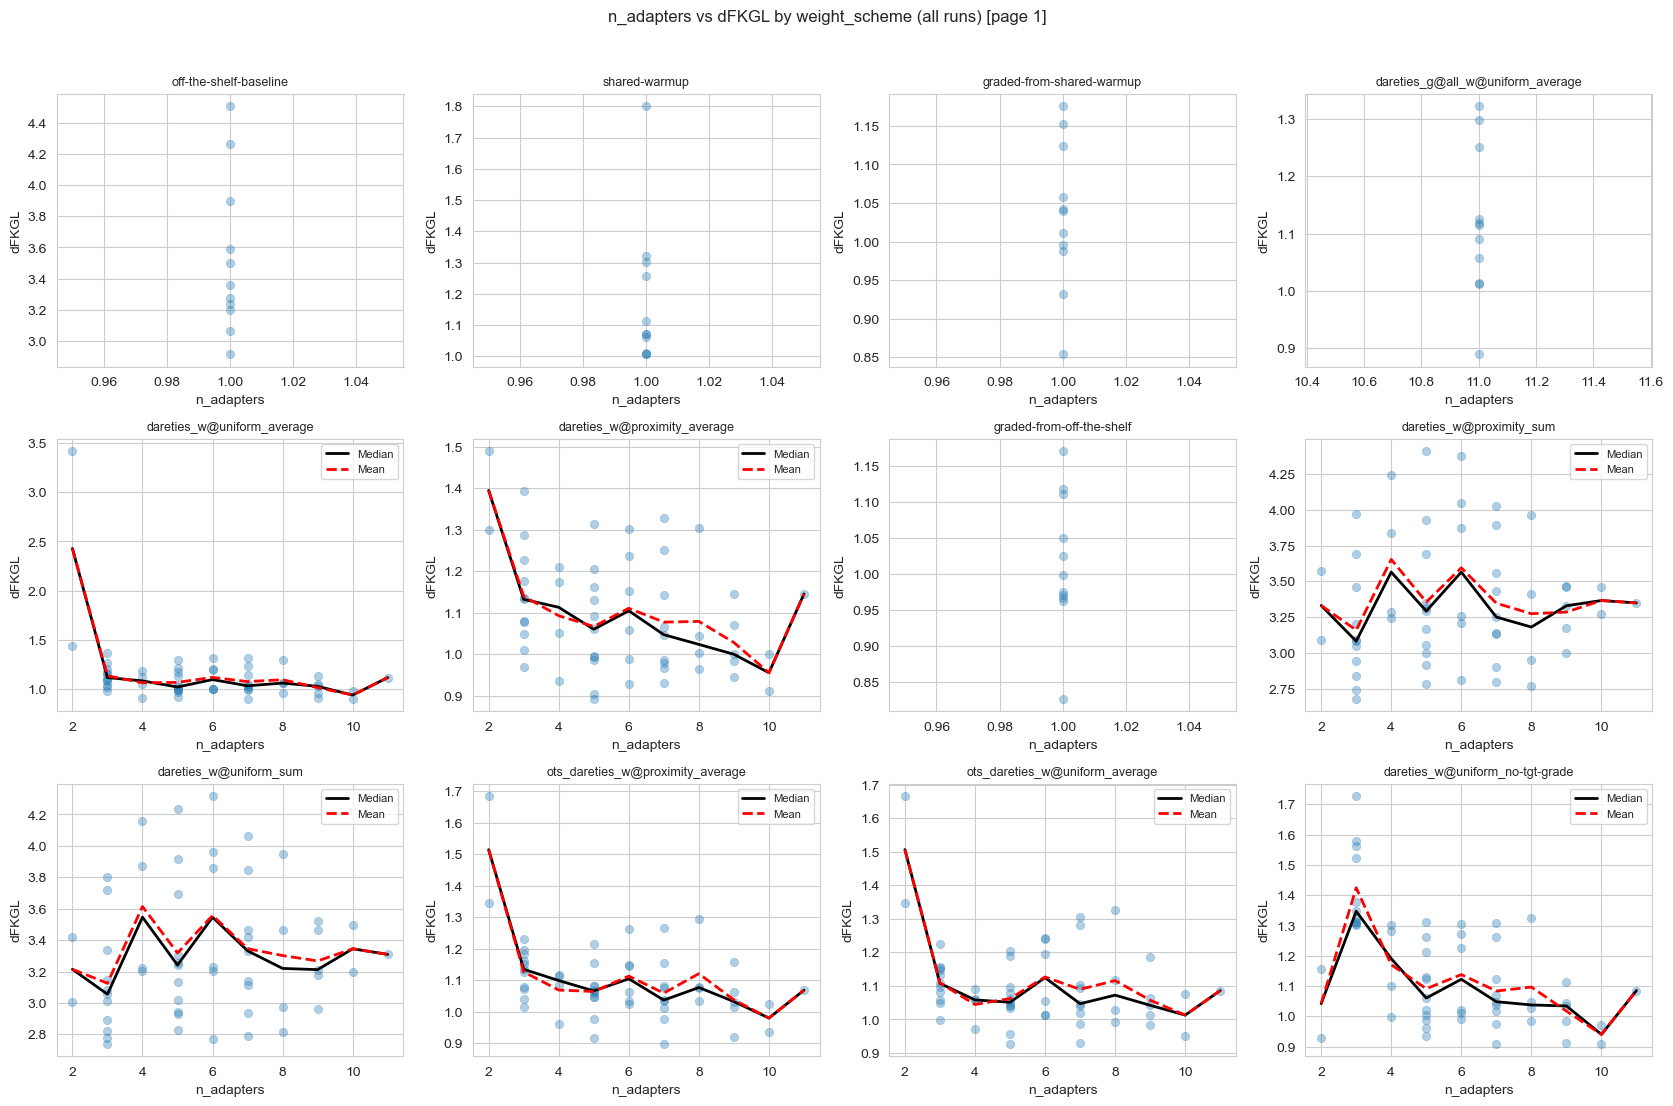

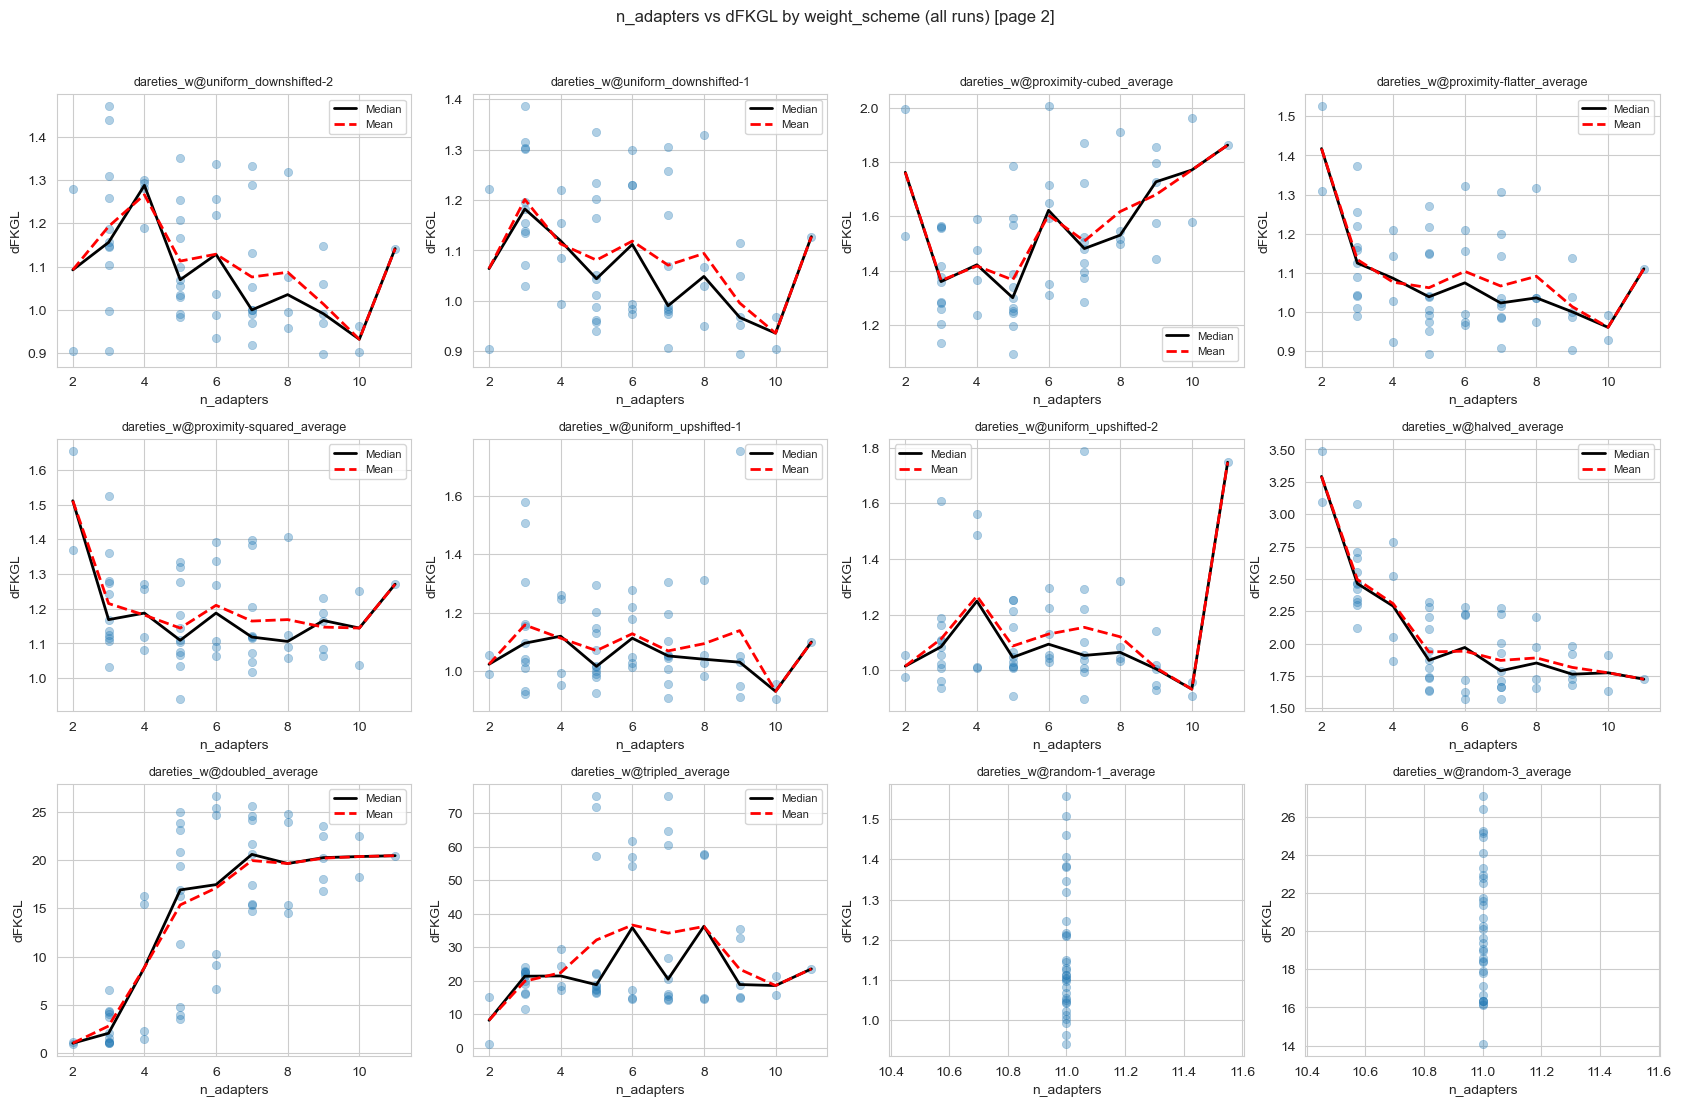

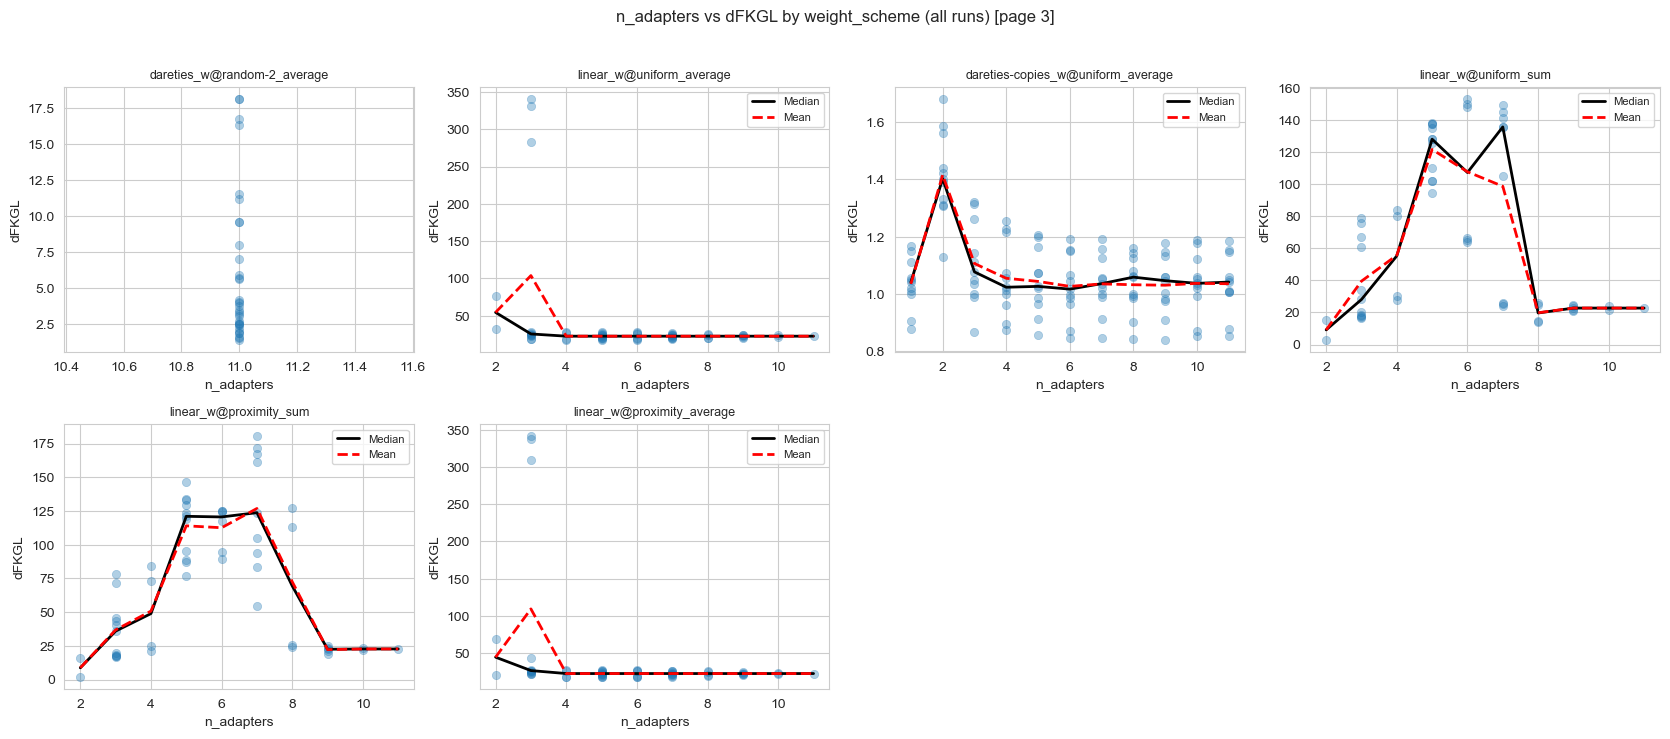

In [72]:
df = results.copy()
plot_schemes_scatter_n_adapters(
    df=df,
    weight_schemes=weight_schemes,
    scheme_col="weight_scheme",   # or "run_name"
    plots_per_fig=12,
    ncols=4,
    only_non_catastrophic=False,   # set False if you want all runs
    y_log=False                   # True if dfkgl still spans wide range
)


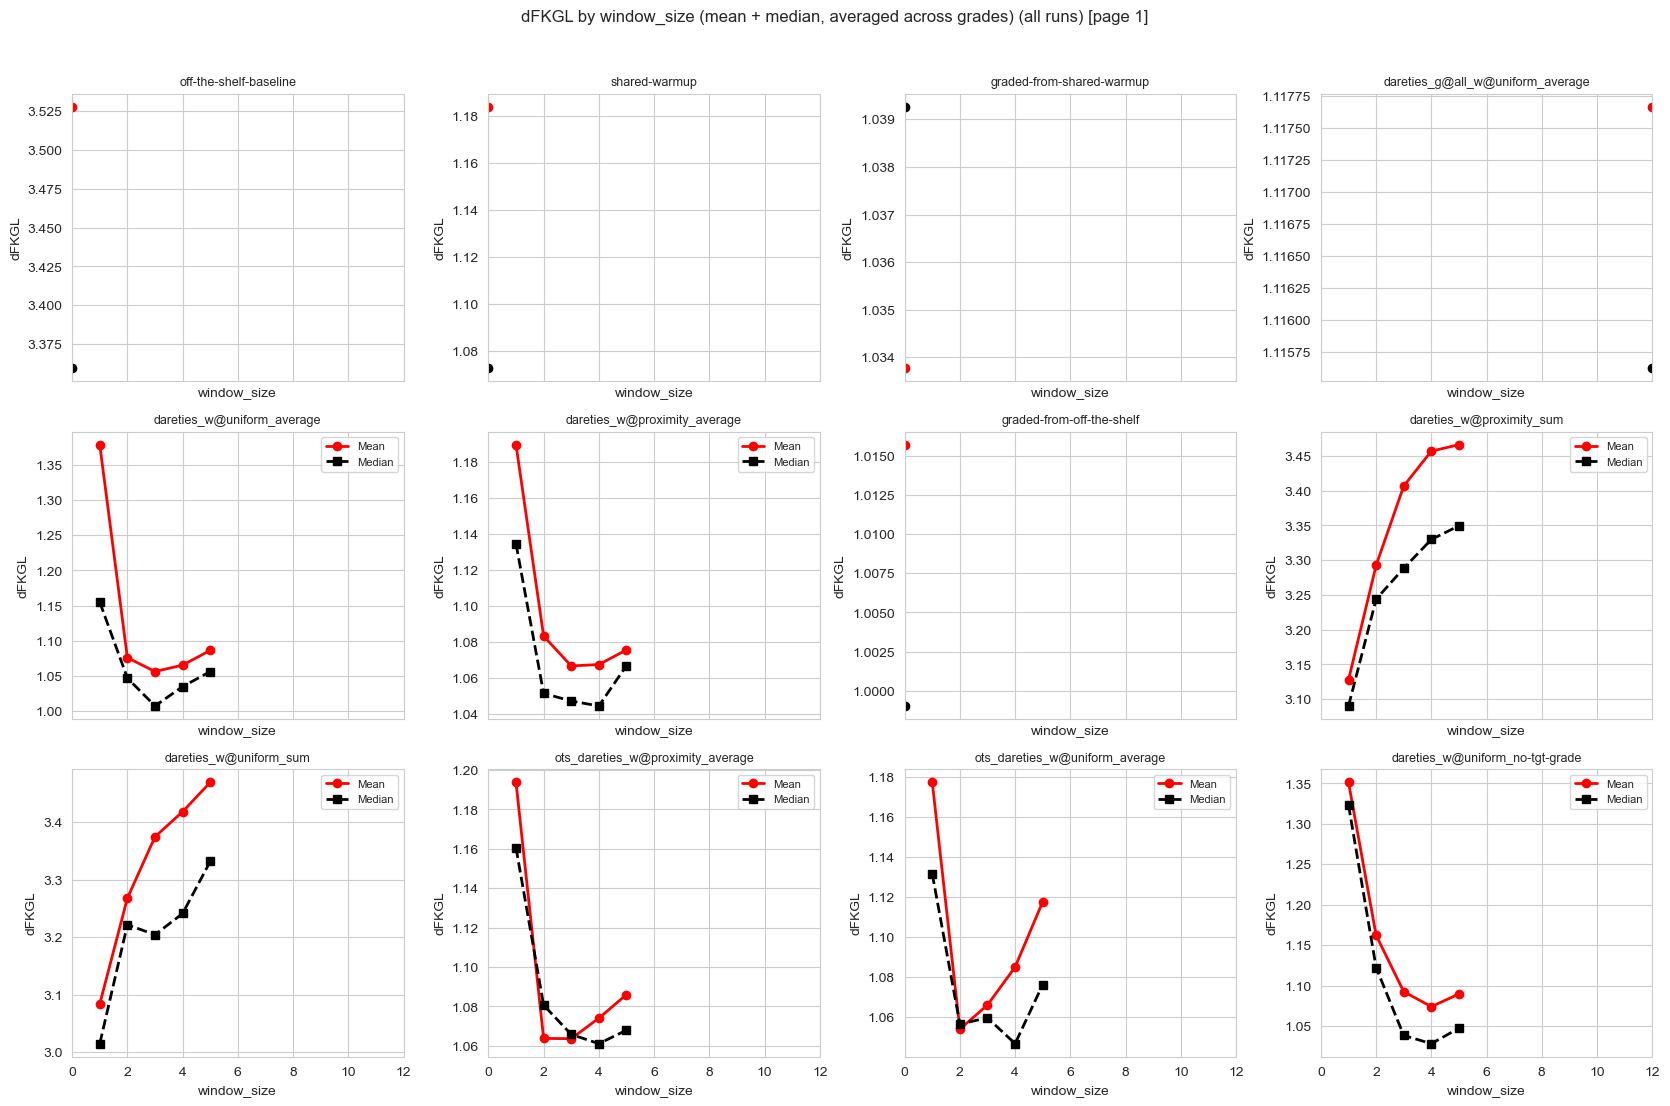

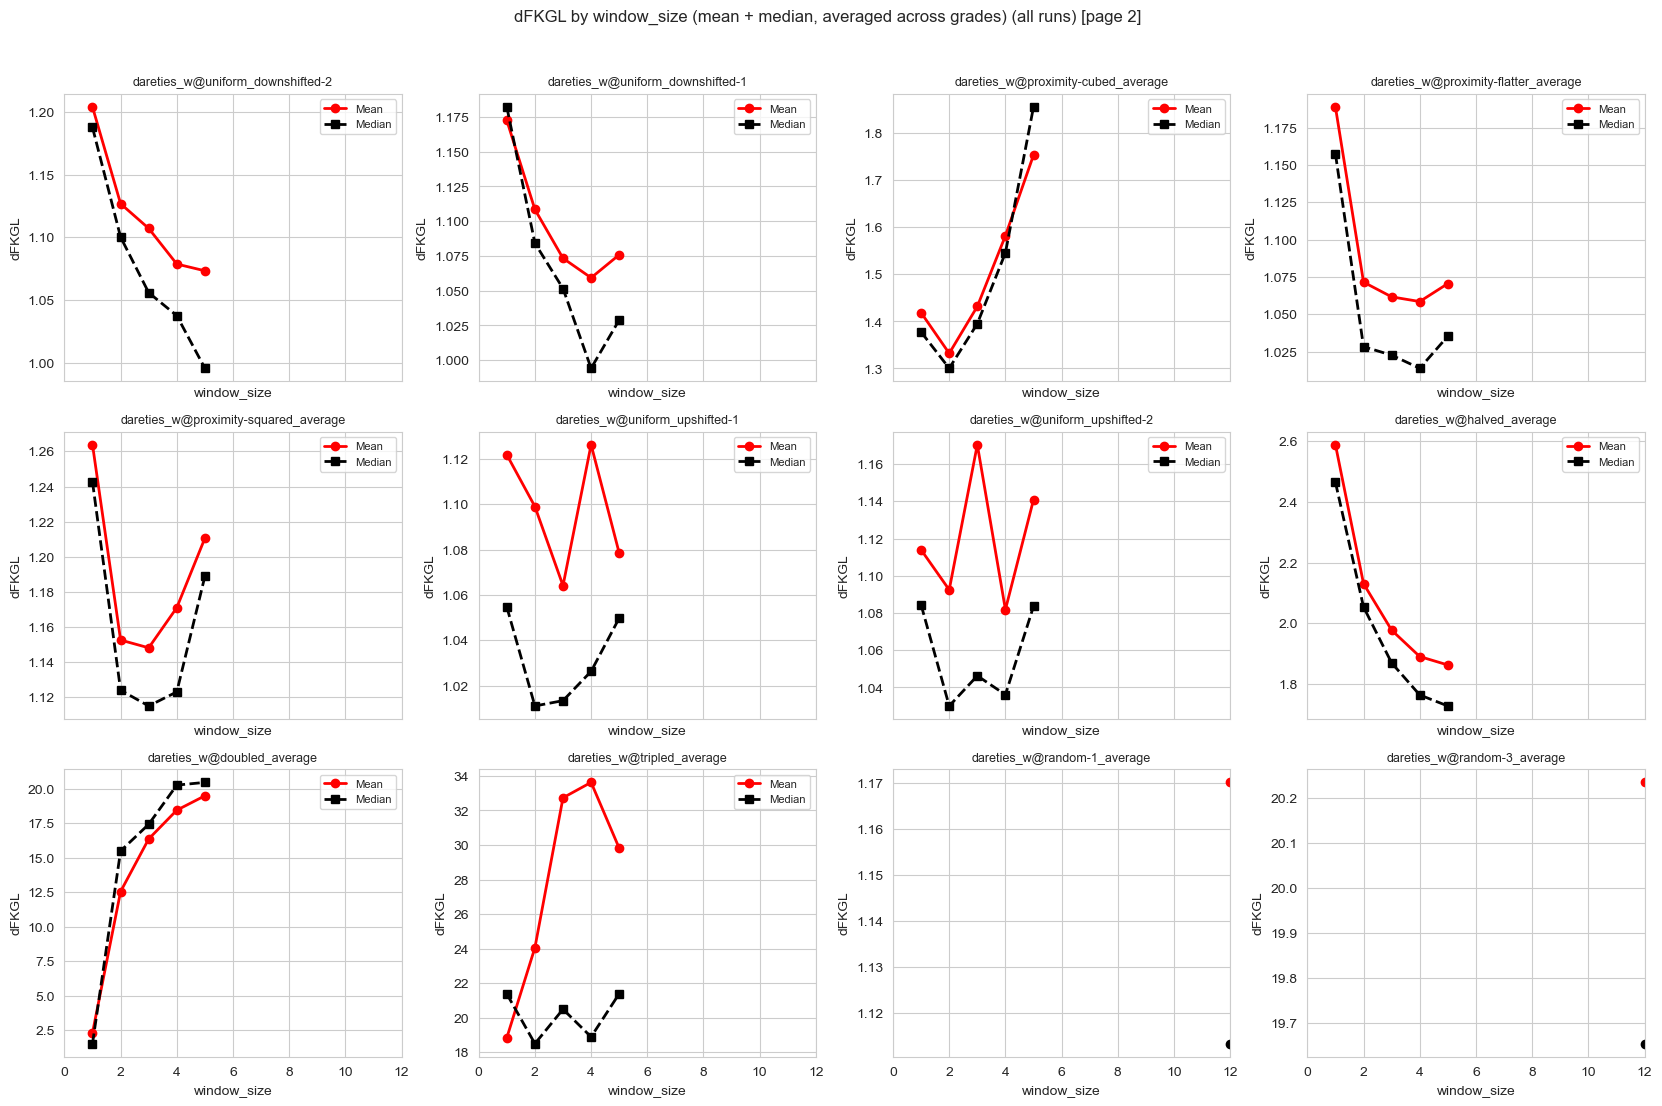

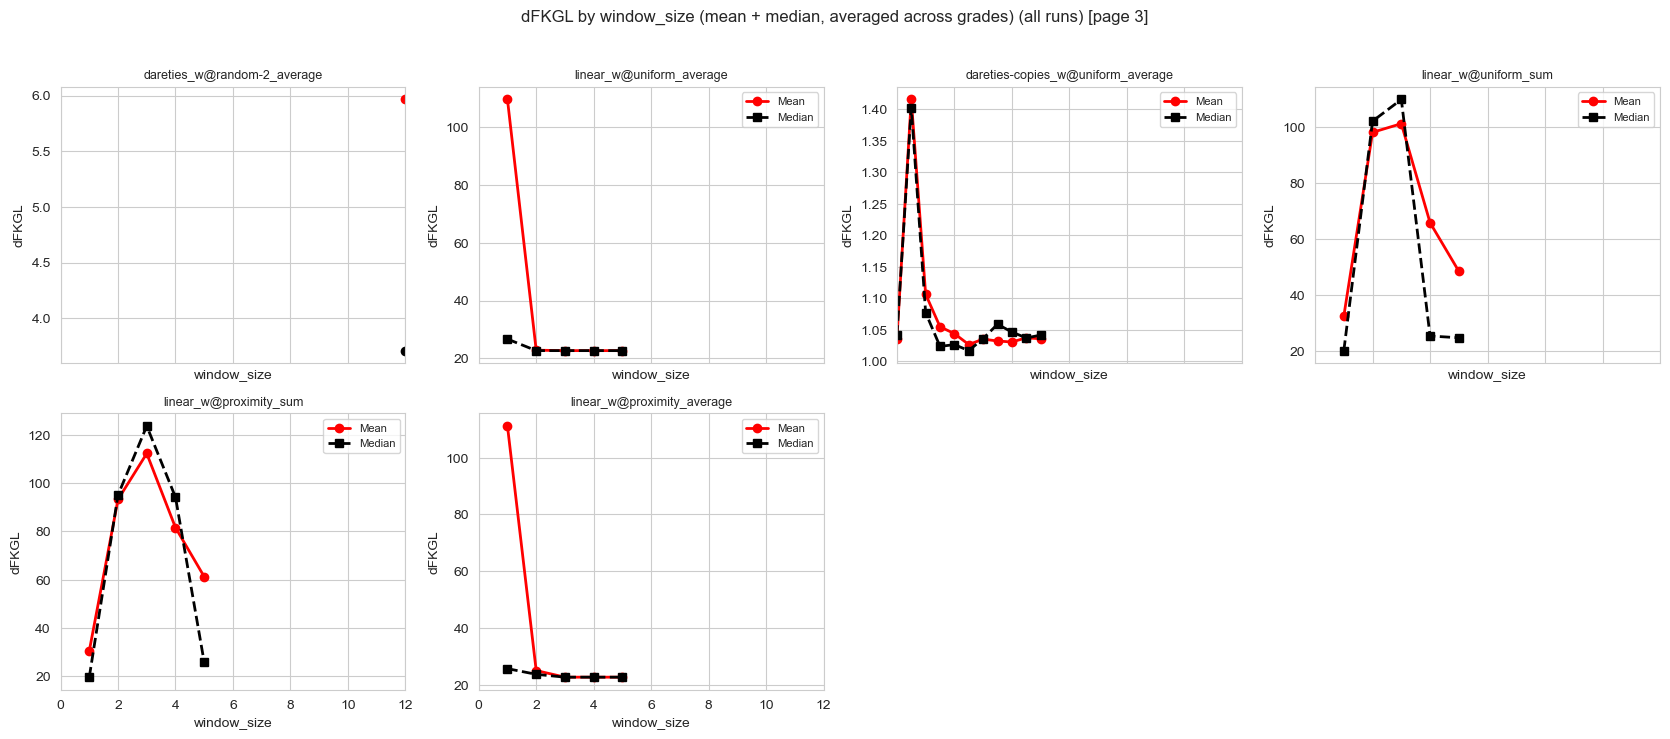

In [73]:
plot_schemes_window_size_mean_by_window(
    df=df,
    weight_schemes=weight_schemes,
    scheme_col="weight_scheme",              # or "weight_scheme"
    only_non_catastrophic=False,
    add_mean_line=True,
    add_median_line=True,
    sharey=False
)

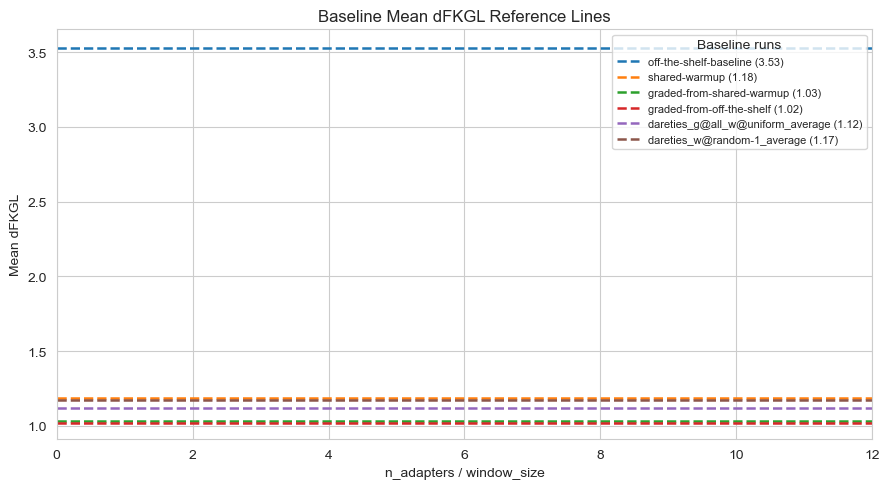

In [94]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

BASELINE_RUN_NAMES = [
    'off-the-shelf-baseline',
    'shared-warmup',
    'graded-from-shared-warmup',
    'graded-from-off-the-shelf',
    'dareties_g@all_w@uniform_average',
    'dareties_w@random-1_average'
]

# Compute mean dFKGL per baseline run (averaged across all grades)
baseline_means = (
    results[results['weight_scheme'].isin(BASELINE_RUN_NAMES)]
    .groupby('weight_scheme')['dfkgl']
    .mean()
    .reindex(BASELINE_RUN_NAMES)  # keep defined order, NaN if missing
)

missing = baseline_means[baseline_means.isna()].index.tolist()
if missing:
    print(f"Warning: these baselines were not found in results: {missing}")

# Distinct colors for each baseline
colors = list(mcolors.TABLEAU_COLORS.values())[:len(BASELINE_RUN_NAMES)]

fig, ax = plt.subplots(figsize=(9, 5))

for (run_name, mean_val), color in zip(baseline_means.items(), colors):
    if pd.isna(mean_val):
        continue
    ax.axhline(
        y=mean_val,
        color=color,
        linewidth=1.8,
        linestyle='--',
        label=f"{run_name} ({mean_val:.2f})"
    )

ax.set_xlim(0, 12)
ax.set_xlabel("n_adapters / window_size")
ax.set_ylabel("Mean dFKGL")
ax.set_title("Baseline Mean dFKGL Reference Lines")
ax.legend(fontsize=8, loc="upper right", frameon=True, title="Baseline runs")

plt.tight_layout()
plt.savefig("./results/plots/baseline_dfkgl_reference.png", dpi=300, bbox_inches="tight")
plt.show()

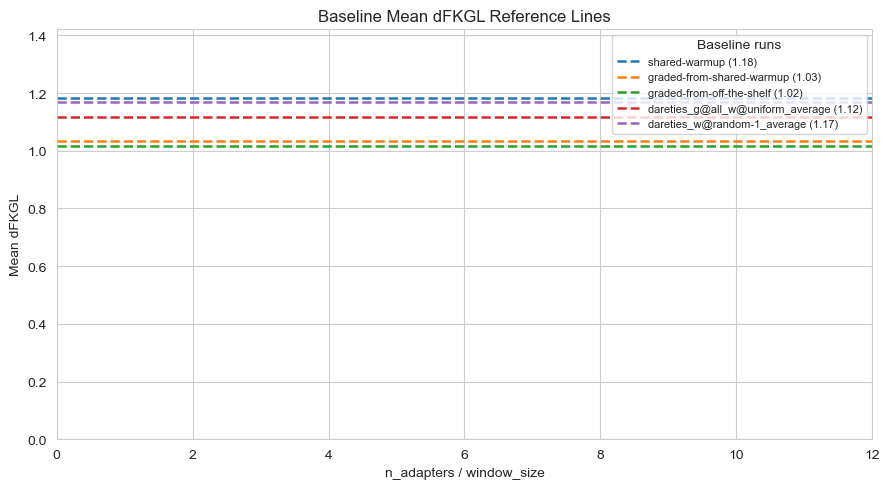

In [96]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

BASELINE_RUN_NAMES = [
    'shared-warmup',
    'graded-from-shared-warmup',
    'graded-from-off-the-shelf',
    'dareties_g@all_w@uniform_average',
    'dareties_w@random-1_average'
]

# Compute mean dFKGL per baseline run (averaged across all grades)
baseline_means = (
    results[results['weight_scheme'].isin(BASELINE_RUN_NAMES)]
    .groupby('weight_scheme')['dfkgl']
    .mean()
    .reindex(BASELINE_RUN_NAMES)  # keep defined order, NaN if missing
)

missing = baseline_means[baseline_means.isna()].index.tolist()
if missing:
    print(f"Warning: these baselines were not found in results: {missing}")

# Distinct colors for each baseline
colors = list(mcolors.TABLEAU_COLORS.values())[:len(BASELINE_RUN_NAMES)]

fig, ax = plt.subplots(figsize=(9, 5))

for (run_name, mean_val), color in zip(baseline_means.items(), colors):
    if pd.isna(mean_val):
        continue
    ax.axhline(
        y=mean_val,
        color=color,
        linewidth=1.8,
        linestyle='--',
        label=f"{run_name} ({mean_val:.2f})"
    )

ax.set_xlim(0, 12)
ax.set_ylim(0, baseline_means.max() * 1.2)  # add some headroom above highest baseline
ax.set_xlabel("n_adapters / window_size")
ax.set_ylabel("Mean dFKGL")
ax.set_title("Baseline Mean dFKGL Reference Lines")
ax.legend(fontsize=8, loc="upper right", frameon=True, title="Baseline runs")

plt.tight_layout()
plt.savefig("./results/plots/baseline_dfkgl_reference.png", dpi=300, bbox_inches="tight")
plt.show()